In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class GridWorld:
    def __init__(self, size, start, goal_state, obstacle_states, trap_state, seed):
        self.size = size
        self.goal = goal_state
        self.obstacles = obstacle_states
        self.trap = trap_state
        self.state = None
        self.seed = seed
        self.start=start
        np.random.seed(seed)

    def reset(self):
        self.state = self.start  # Start state

    def step(self, action):

        current_state = self.state

        if action == 'N':
            next_state = [self.state[0] - 1, self.state[1]]
        elif action == 'S':
            next_state = [self.state[0] + 1, self.state[1]]
        elif action == 'E':
            next_state = [self.state[0], self.state[1] + 1]
        elif action == 'W':
            next_state = [self.state[0], self.state[1] - 1]
        else:
            raise ValueError("Invalid action")

        # Check if the next state is valid
        if self.is_valid_state(next_state):
            self.state = next_state
            reward = self.get_reward(self.state)
        else:
            reward = self.get_reward(next_state)
            #added next state as self state
            next_state = self.state

        is_terminal = self.is_terminal_state(next_state)



        return self.state, reward, is_terminal

    def is_valid_state(self, state):
        row, col = state
        # Check if within valid grid boundaries and not in obstacles
        if (1 <= row <= self.size) and (1 <= col <= self.size) and ([row, col] not in self.obstacles):
            return True
        return False

    def is_terminal_state(self, state):
        # Check if the state is the goal state
        if state == self.goal or state == self.trap:
            return True
        return False

    def get_reward(self, state):
        # Return the reward for the given state
        if state == self.goal:
            return 5  # Goal reward
        elif state == self.trap:
            return -5
        elif (state[0] < 1) or (state[1] < 1) or (state[0] > self.size) or (state[1] > self.size):
            return -1 # Out of Bounds reward
        else:
            return 0

    def plot_grid(self, policy=None, plot_policy_flag=False):
        plt.figure()
        ax = plt.gca()

        # Plot gridlines
        for i in range(1, self.size):
            ax.axhline(i, color='k', linestyle='-', linewidth=1)
            ax.axvline(i, color='k', linestyle='-', linewidth=1)

        ax.plot(self.start[1] - 0.5, self.start[0] - 0.5, 'bo', markerfacecolor='b', markersize=20)
        # Plot goal state
        ax.plot(self.goal[1] - 0.5, self.goal[0] - 0.5, 'gs', markerfacecolor='g', markersize=30)

        # Plot obstacles
        for obstacle in self.obstacles:
            ax.plot(obstacle[1] - 0.5, obstacle[0] - 0.5, 'ks', markerfacecolor='k', markersize=30)

        # Plot Trap
        ax.plot(self.trap[1] - 0.5, self.trap[0] - 0.5, 'rs', markerfacecolor='r', markersize=30)

        # Plot current state
        ax.plot(self.state[1] - 0.5, self.state[0] - 0.5, 'ro', markerfacecolor='r', markersize=20)

        if plot_policy_flag and policy is not None:
            self.plot_policy_arrows(policy, self.start)

        ax.set_xlim([0, self.size])
        ax.set_ylim([self.size, 0])
        ax.set_xticks(np.arange(self.size))
        ax.set_yticks(np.arange(self.size))
        ax.grid(True)
        ax.set_aspect('equal')
        plt.show()

    def plot_policy_arrows(self, policy, start):
        for i in range(self.size):
            for j in range(self.size):
                if [i + 1, j + 1] != self.goal and [i + 1, j + 1] != self.trap and [i + 1, j + 1] not in self.obstacles:
                    action = policy[i, j]
                    if action == 0:  # North
                        dx, dy = 0, -0.3
                    elif action == 1:  # South
                        dx, dy = 0, 0.3
                    elif action == 2:  # East
                        dx, dy = 0.3, 0
                    elif action == 3:  # West
                        dx, dy = -0.3, 0
                    else:
                        continue

                    plt.arrow(j + 0.5, i + 0.5, dx, dy, head_width=0.1, head_length=0.1, fc='k', ec='k')
                    plt.title('Converged Policy')


In [3]:
class BridgeGridWorld(GridWorld):
    def __init__(self, size, start, goal_state, obstacle_states, trap_state, seed, bridge_state):
        super().__init__(size, start, goal_state, obstacle_states, trap_state, seed)
        self.bridge_state = bridge_state
        self.bridge_col = bridge_state[1]
        self.total_cols = size * 2 + 1

        # Override size to represent total number of columns for state calculations
        self.grid_rows = self.size  # Keep original rows
        self.grid_cols = self.total_cols  # Total columns including bridge

        # Explicitly define wall coordinates (entire bridge column except bridge)
        self.walls = [[r, self.bridge_col] for r in range(1, self.grid_rows + 1)
                      if [r, self.bridge_col] != self.bridge_state]

    def is_valid_state(self, state):
        row, col = state

        if (1 <= row <= self.grid_rows) and (1 <= col <= self.grid_cols) and (state not in self.walls) and (state not in self.obstacles):
            return True
        return False

    def get_reward(self, state):
        if state == self.goal:
            return 5  # Goal reward
        elif state == self.trap:
            return -5
        elif (state[0] < 1) or (state[1] < 1) or (state[0] > self.grid_rows) or (state[1] > self.grid_cols) or (state in self.walls):
            return -1
        else:
            return 0

    def plot_grid(self, policy=None, plot_policy_flag=False):
        """
        Extend plotter to show explicit wall column (bridge col walls).
        """
        plt.figure(figsize=(8, 5))
        ax = plt.gca()
        total_size = self.grid_cols

        # Draw gridlines
        for i in range(1, total_size):
            ax.axhline(i, color='gray', linestyle='-', linewidth=0.5)
            ax.axvline(i, color='gray', linestyle='-', linewidth=0.5)

        # Start, goal, trap
        ax.plot(self.start[1] - 0.5, self.start[0] - 0.5, 'bo', markersize=20, label='Start')
        ax.plot(self.goal[1] - 0.5, self.goal[0] - 0.5, 'gs', markersize=25, label='Goal')
        ax.plot(self.trap[1] - 0.5, self.trap[0] - 0.5, 'rs', markersize=25, label='Trap')

        # Obstacles (black)
        for obs in self.obstacles:
            ax.plot(obs[1] - 0.5, obs[0] - 0.5, 'ks', markersize=25)

        # Bridge walls (gray)
        for wall in self.walls:
            ax.plot(wall[1] - 0.5, wall[0] - 0.5, 's', color='lightgray', markersize=25)

        # Current state
        ax.plot(self.state[1] - 0.5, self.state[0] - 0.5, 'mo', markersize=15)

        # Optional policy arrows
        if plot_policy_flag and policy is not None:
            self.plot_policy_arrows(policy, self.start)

        ax.set_xlim([0, total_size])
        ax.set_ylim([self.grid_rows, 0])
        ax.set_xticks(np.arange(total_size))
        ax.set_yticks(np.arange(self.grid_rows))
        ax.grid(True)
        ax.set_aspect('equal')
        plt.title("Bridge GridWorld")
        plt.show()

    def plot_policy_arrows(self, policy, start):
        """Override to handle the larger grid dimensions."""
        for i in range(self.grid_rows):
            for j in range(self.grid_cols):
                state_pos = [i + 1, j + 1]
                # Skip goal, trap, obstacles, and walls
                if (state_pos != self.goal and state_pos != self.trap and
                    state_pos not in self.obstacles and state_pos not in self.walls):

                    action = policy[i, j]
                    if action == 0:  # North
                        dx, dy = 0, -0.3
                    elif action == 1:  # South
                        dx, dy = 0, 0.3
                    elif action == 2:  # East
                        dx, dy = 0.3, 0
                    elif action == 3:  # West
                        dx, dy = -0.3, 0
                    else:
                        continue

                    plt.arrow(j + 0.5, i + 0.5, dx, dy, head_width=0.1, head_length=0.1, fc='k', ec='k')
        plt.title('Converged Policy')


In [4]:
class Qlearning:
    def __init__(self, env, alpha, episodes, seed, gamma=0.9, epsilon=0.1):
        self.env = env
        self.alpha = alpha
        self.episodes = episodes
        self.gamma = gamma
        self.epsilon = epsilon
        self.num_actions = 4
        


        if hasattr(env, 'grid_rows') and hasattr(env, 'grid_cols'):
            self.num_states = env.grid_rows * env.grid_cols
            self.grid_rows = env.grid_rows
            self.grid_cols = env.grid_cols
            self.max_steps = env.grid_rows * env.grid_cols * 10
        else:
            self.num_states = env.size * env.size
            self.grid_rows = env.size
            self.grid_cols = env.size
            self.max_steps = env.size * env.size * 10

        # Set random seed for reproducibility
        np.random.seed(seed)

        # Initialize Q-table with small random values
        self.Q = 0.001 * np.random.rand(self.num_states, self.num_actions)

        # Training metrics
        self.steps_per_episode = []
        self.rewards_per_episode = []
        self.success_rate_history = []

        # Track episode outcomes during training
        self.episode_outcomes = []

        # Action mapping
        self.action_map = {0: 'N', 1: 'S', 2: 'E', 3: 'W'}

    def get_state(self, coordinates, grid_size):
        """Convert grid coordinates to state index."""
        if hasattr(self.env, 'grid_cols'):
            return (coordinates[0] - 1) * self.grid_cols + coordinates[1]
        else:
            return (coordinates[0] - 1) * grid_size + coordinates[1]


    # def softmax_action_selection(self, state):
    #     """Select an action using the Softmax (Boltzmann) policy."""
    #     q_values = self.Q[state - 1, :]

    #     max_q = np.max(q_values)
    #     exp_q = np.exp(self.epsilon * (q_values - max_q))
    #     probs = exp_q / np.sum(exp_q)

    #     action_idx = np.random.choice(len(probs), p=probs)
    #     return action_idx

    def softmax_action_selection(self, state):
        """Select an action using the Softmax (Boltzmann) policy."""
        q_values = self.Q[state - 1, :]

        scaled_q_values = q_values / self.epsilon
        stable_q = scaled_q_values - np.max(scaled_q_values)
        probs = np.exp(stable_q) / np.sum(np.exp(stable_q))

        # sample from the probability distribution
        action_idx = np.random.choice(self.num_actions, p=probs)
        return action_idx


    def epsilon_greedy_action(self, state, epsilon=None):
        """Choose action using epsilon-greedy policy."""
        if epsilon is None:
            epsilon = self.epsilon

        if np.random.rand() < epsilon:
            action_idx = np.random.randint(self.num_actions)
        else:
            action_idx = np.argmax(self.Q[state-1, :])
        return action_idx

    def train(self, verbose=True, track_metrics=True, softmax=False):
        """Train the Q-learning agent."""
        if verbose:
            print(f"Starting Q-learning training...")
            print(f"Episodes: {self.episodes}, Learning Rate: {self.alpha}")
            print(f"Discount Factor: {self.gamma}, Epsilon: {self.epsilon}")
            print("-" * 60)

        for episode in range(self.episodes):
            self.env.reset()
            current_state = self.get_state(self.env.state, self.env.size)

            episode_steps = 0
            episode_reward = 0
            episode_outcome = 'timeout'

            for step in range(self.max_steps):
                if softmax:
                    action_idx = self.softmax_action_selection(current_state)
                else:
                    action_idx = self.epsilon_greedy_action(current_state)
                action = self.action_map[action_idx]

                next_state, reward, is_terminal = self.env.step(action)
                next_state_idx = self.get_state(next_state, self.env.size)

                self.Q[current_state-1, action_idx] += self.alpha * (
                    reward + self.gamma * np.max(self.Q[next_state_idx-1, :]) -
                    self.Q[current_state-1, action_idx]
                )

                current_state = next_state_idx
                episode_steps += 1
                episode_reward += reward

                if is_terminal:
                    if self.env.state == self.env.goal:
                        episode_outcome = 'goal'
                    elif self.env.state == self.env.trap:
                        episode_outcome = 'trap'
                    break

            if track_metrics:
                self.steps_per_episode.append(episode_steps)
                self.rewards_per_episode.append(episode_reward)
                self.episode_outcomes.append(episode_outcome)


        if verbose:
            print("-" * 60)
            print("Training completed!")

        return {
            'Q_table': self.Q.copy(),
            'steps_per_episode': self.steps_per_episode,
            'rewards_per_episode': self.rewards_per_episode,
            'success_rate_history': self.success_rate_history,
            'episode_outcomes': self.episode_outcomes
        }

    def get_training_statistics(self):
        if not self.episode_outcomes:
            print("No training data available. Run train() first.")
            return None

        goal_count = self.episode_outcomes.count('goal')
        trap_count = self.episode_outcomes.count('trap')
        timeout_count = self.episode_outcomes.count('timeout')
        total_episodes = len(self.episode_outcomes)

        return {
            'total_episodes': total_episodes,
            'goal_episodes': goal_count,
            'trap_episodes': trap_count,
            'timeout_episodes': timeout_count,
            'success_rate': goal_count / total_episodes,
            'trap_rate': trap_count / total_episodes,
            'timeout_rate': timeout_count / total_episodes,
            'failure_rate': (trap_count + timeout_count) / total_episodes,
            'avg_steps': np.mean(self.steps_per_episode),
            'avg_reward': np.mean(self.rewards_per_episode),
            'total_steps': sum(self.steps_per_episode),
            'total_reward': sum(self.rewards_per_episode)
        }


    def get_policy_and_value_function(self, goal_reward=5, trap_penalty=-5):
        """Extract policy and value function from Q-table."""
        policy = np.zeros((self.grid_rows, self.grid_cols), dtype=int)
        value_function = np.zeros((self.grid_rows, self.grid_cols))

        for i in range(self.grid_rows):
            for j in range(self.grid_cols):
                state = self.get_state([i + 1, j + 1], self.env.size)

                best_action = np.argmax(self.Q[state-1, :])
                policy[i, j] = best_action

                value_function[i, j] = np.max(self.Q[state-1, :])

                if [i + 1, j + 1] == self.env.goal:
                    value_function[i, j] = goal_reward
                elif [i + 1, j + 1] == self.env.trap:
                    value_function[i, j] = trap_penalty

        return policy, value_function

    def plot_policy_and_value(self, goal_reward=5, trap_penalty=-5):
        """Plot the learned policy and value function."""
        policy, value_function = self.get_policy_and_value_function(goal_reward, trap_penalty)

        self.env.plot_grid(policy, plot_policy_flag=True)

        plt.figure(figsize=(12, 5) if self.grid_cols > self.grid_rows else (8, 6))
        plt.imshow(value_function, cmap='hot', interpolation='nearest')
        plt.colorbar(label='State Value')
        plt.title(f'Value Function (α={self.alpha}, γ={self.gamma}, ε={self.epsilon})')
        plt.xlabel('Columns')
        plt.ylabel('Rows')
        plt.xticks(np.arange(self.grid_cols))
        plt.yticks(np.arange(self.grid_rows))
        plt.grid(True, alpha=0.3)
        plt.show()

        return policy, value_function

    @staticmethod
    def calculate_epoch_statistics(all_steps, all_rewards):

        # Calculate average and standard deviation across epochs
        avg_steps = np.mean(all_steps, axis=0)
        std_steps = np.std(all_steps, axis=0)
        avg_rewards = np.mean(all_rewards, axis=0)
        std_rewards = np.std(all_rewards, axis=0)

        # Calculate cumulative average reward and its std
        cumulative_avg_reward = np.cumsum(avg_rewards) / np.arange(1, len(avg_rewards) + 1)

        # For cumulative std, calculate it from the cumulative sums of each epoch
        cumulative_rewards = [np.cumsum(epoch_rewards) / np.arange(1, len(epoch_rewards) + 1)
                             for epoch_rewards in all_rewards]
        std_cumulative_avg_reward = np.std(cumulative_rewards, axis=0)

        return {
            'avg_steps': avg_steps,
            'std_steps': std_steps,
            'avg_rewards': avg_rewards,
            'std_rewards': std_rewards,
            'cumulative_avg_reward': cumulative_avg_reward,
            'std_cumulative_avg_reward': std_cumulative_avg_reward
        }

    @staticmethod
    def run_multiple_epochs(env_config, alpha, episodes, gamma, epsilon_values, num_epochs=20, verbose=False):
        results = {}

        for epsilon in epsilon_values:
            if verbose:
                print(f"\n{'='*70}")
                print(f"Training with ε = {epsilon} (γ = {gamma})")
                print(f"{'='*70}")

            all_steps = []
            all_rewards = []

            for epoch in range(num_epochs):
                if verbose:
                    print(f"Epoch {epoch+1}/{num_epochs}...", end=' ')

                
                epoch_seed = env_config['seed'] + epoch

                env = GridWorld(
                    size=env_config['size'],
                    start=env_config['start'],
                    goal_state=env_config['goal_state'],
                    obstacle_states=env_config['obstacle_states'],
                    trap_state=env_config['trap_state'],
                    seed=epoch_seed
                )

                agent = Qlearning(env, alpha, episodes, seed=epoch_seed,
                                gamma=gamma, epsilon=epsilon)

                agent.train(verbose=False, track_metrics=True)

                all_steps.append(agent.steps_per_episode)
                all_rewards.append(agent.rewards_per_episode)

                if verbose:
                    print(f"Done")

            # Calculate statistics using the dedicated method
            epoch_stats = Qlearning.calculate_epoch_statistics(all_steps, all_rewards)
            results[epsilon] = epoch_stats

            if verbose:
                print(f"Completed ε = {epsilon}")

        return results
    
    @staticmethod
    def run_multiple_epochs_bridge(bridge_config, alpha, episodes, gamma, epsilon_values, num_epochs=20, verbose=False):

        results = {}

        for epsilon in epsilon_values:
            if verbose:
                print(f"\n{'='*70}")
                print(f"Training BridgeGridWorld with β/ε = {epsilon} (γ = {gamma})")
                print(f"{'='*70}")

            all_steps = []
            all_rewards = []

            for epoch in range(num_epochs):
                if verbose:
                    print(f"Epoch {epoch+1}/{num_epochs}...", end=' ')

                epoch_seed = bridge_config['seed'] + epoch
                
                env = BridgeGridWorld(
                    size=bridge_config['size'],
                    start=bridge_config['start'],
                    goal_state=bridge_config['goal_state'],
                    obstacle_states=bridge_config['obstacle_states'],
                    trap_state=bridge_config['trap_state'],
                    seed=epoch_seed,
                    bridge_state=bridge_config['bridge_state']
                )

                # Create agent with epoch-specific seed
                agent = Qlearning(env, alpha, episodes, seed=epoch_seed,
                                gamma=gamma, epsilon=epsilon)

                # Train with softmax=True
                agent.train(verbose=False, track_metrics=True, softmax=True)

                all_steps.append(agent.steps_per_episode)
                all_rewards.append(agent.rewards_per_episode)

                if verbose:
                    print(f"Done")

            # Calculate statistics using the dedicated method
            epoch_stats = Qlearning.calculate_epoch_statistics(all_steps, all_rewards)
            results[epsilon] = epoch_stats

            if verbose:
                print(f"Completed β/ε = {epsilon}")

        return results

    @staticmethod
    def run_single_epoch(env_config, alpha, episodes, gamma, epsilon_values, verbose=False):
        results = {}

        for epsilon in epsilon_values:
            if verbose:
                print(f"Training with ε = {epsilon} (γ = {gamma})...", end=' ')

            # Create environment and agent
            env = GridWorld(
                size=env_config['size'],
                start=env_config['start'],
                goal_state=env_config['goal_state'],
                obstacle_states=env_config['obstacle_states'],
                trap_state=env_config['trap_state'],
                seed=env_config['seed']
            )

            agent = Qlearning(env, alpha, episodes, seed=env_config['seed'],
                            gamma=gamma, epsilon=epsilon)

            agent.train(verbose=False, track_metrics=True)

            # Calculate cumulative average reward
            cumulative_avg_reward = np.cumsum(agent.rewards_per_episode) / np.arange(1, len(agent.rewards_per_episode) + 1)

            results[epsilon] = {
                'steps': np.array(agent.steps_per_episode),
                'rewards': np.array(agent.rewards_per_episode),
                'cumulative_avg_reward': cumulative_avg_reward
            }

            if verbose:
                print(f"Done")

        return results

    @staticmethod
    def plot_single_epoch_results(results, gamma, episodes):

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        episode_range = np.array(range(1, episodes + 1))
        colors = ['blue', 'green', 'red']

        # Plot 1: Log Episodes vs Steps to Goal
        for idx, (epsilon, data) in enumerate(results.items()):
            ax1.plot(episode_range, data['steps'],
                    label=f'ε = {epsilon}', color=colors[idx], linewidth=2, alpha=0.8)

        ax1.set_xscale('log')
        ax1.set_xlabel('Log Episodes', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Steps to Reach Goal', fontsize=12, fontweight='bold')
        ax1.set_title(f'Steps to Goal vs Log Episodes (γ = {gamma})\nSingle Epoch Test',
                     fontsize=14, fontweight='bold')
        ax1.legend(fontsize=11)
        ax1.grid(True, alpha=0.3)

        # Plot 2: Log Episodes vs Cumulative Average Reward
        for idx, (epsilon, data) in enumerate(results.items()):
            ax2.plot(episode_range, data['cumulative_avg_reward'],
                    label=f'ε = {epsilon}', color=colors[idx], linewidth=2, alpha=0.8)

        ax2.set_xscale('log')
        ax2.set_xlabel('Log Episodes', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Cumulative Average Reward', fontsize=12, fontweight='bold')
        ax2.set_title(f'Cumulative Average Reward vs Log Episodes (γ = {gamma})\nSingle Epoch Test',
                     fontsize=14, fontweight='bold')
        ax2.legend(fontsize=11)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Print summary statistics
        print(f"\n{'='*70}")
        print(f"SINGLE EPOCH TEST RESULTS (γ = {gamma})")
        print(f"{'='*70}")
        for epsilon, data in results.items():
            print(f"\nε = {epsilon}:")
            print(f"  Final Steps to Goal: {data['steps'][-1]}")
            print(f"  Final Cumulative Avg Reward: {data['cumulative_avg_reward'][-1]:.4f}")
            print(f"  Mean Steps (all episodes): {np.mean(data['steps']):.2f}")
            print(f"  Mean Reward (all episodes): {np.mean(data['rewards']):.4f}")
        print(f"{'='*70}\n")

    @staticmethod
    def plot_epsilon_comparison(results, gamma, episodes):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        episode_range = np.array(range(1, episodes + 1))
        colors = ['blue', 'green', 'red']

        # Plot 1: Log Episodes vs Steps to Goal (with std deviation)
        for idx, (epsilon, data) in enumerate(results.items()):
            ax1.plot(episode_range, data['avg_steps'],
                    label=f'ε = {epsilon}', color=colors[idx], linewidth=2, alpha=0.8)
            ax1.fill_between(episode_range,
                           data['avg_steps'] - data['std_steps'],
                           data['avg_steps'] + data['std_steps'],
                           color=colors[idx], alpha=0.2)

        ax1.set_xscale('log')
        ax1.set_xlabel('Log Episodes', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Steps to Reach Goal', fontsize=12, fontweight='bold')
        ax1.set_title(f'Steps to Goal vs Log Episodes (γ = {gamma})\n(Shaded area = ±1 std)',
                     fontsize=14, fontweight='bold')
        ax1.legend(fontsize=11)
        ax1.grid(True, alpha=0.3)

        # Plot 2: Log Episodes vs Cumulative Average Reward (with std deviation)
        for idx, (epsilon, data) in enumerate(results.items()):
            ax2.plot(episode_range, data['cumulative_avg_reward'],
                    label=f'ε = {epsilon}', color=colors[idx], linewidth=2, alpha=0.8)
            ax2.fill_between(episode_range,
                           data['cumulative_avg_reward'] - data['std_cumulative_avg_reward'],
                           data['cumulative_avg_reward'] + data['std_cumulative_avg_reward'],
                           color=colors[idx], alpha=0.2)

        ax2.set_xscale('log')
        ax2.set_xlabel('Log Episodes', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Cumulative Average Reward', fontsize=12, fontweight='bold')
        ax2.set_title(f'Cumulative Average Reward vs Log Episodes (γ = {gamma})\n(Shaded area = ±1 std)',
                     fontsize=14, fontweight='bold')
        ax2.legend(fontsize=11)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_epsilon_separate(results, gamma, episodes):
        episode_range = np.array(range(1, episodes + 1))
        colors = {'0.1': 'blue', '0.3': 'green', '0.5': 'red'}

        for epsilon, data in results.items():
            # Create a figure with 2 subplots for each epsilon
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
            color = colors.get(str(epsilon), 'purple')

            # Plot 1: Log Episodes vs Steps to Goal
            ax1.plot(episode_range, data['avg_steps'],
                    color=color, linewidth=2, alpha=0.8, label='Mean')
            ax1.fill_between(episode_range,
                           data['avg_steps'] - data['std_steps'],
                           data['avg_steps'] + data['std_steps'],
                           color=color, alpha=0.2, label='±1 std')

            ax1.set_xscale('log')
            ax1.set_xlabel('Log Episodes', fontsize=12, fontweight='bold')
            ax1.set_ylabel('Steps to Reach Goal', fontsize=12, fontweight='bold')
            ax1.set_title(f'Steps to Goal vs Log Episodes\nε = {epsilon}, γ = {gamma} (Averaged over 20 epochs)',
                         fontsize=14, fontweight='bold')
            ax1.legend(fontsize=11)
            ax1.grid(True, alpha=0.3)

            # Plot 2: Log Episodes vs Cumulative Average Reward
            ax2.plot(episode_range, data['cumulative_avg_reward'],
                    color=color, linewidth=2, alpha=0.8, label='Mean')
            ax2.fill_between(episode_range,
                           data['cumulative_avg_reward'] - data['std_cumulative_avg_reward'],
                           data['cumulative_avg_reward'] + data['std_cumulative_avg_reward'],
                           color=color, alpha=0.2, label='±1 std')

            ax2.set_xscale('log')
            ax2.set_xlabel('Log Episodes', fontsize=12, fontweight='bold')
            ax2.set_ylabel('Cumulative Average Reward', fontsize=12, fontweight='bold')
            ax2.set_title(f'Cumulative Average Reward vs Log Episodes\nε = {epsilon}, γ = {gamma} (Averaged over 20 epochs)',
                         fontsize=14, fontweight='bold')
            ax2.legend(fontsize=11)
            ax2.grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

            print(f"\n{'='*70}")
            print(f"STATISTICS FOR ε = {epsilon}")
            print(f"{'='*70}")
            print(f"Final Average Steps to Goal: {data['avg_steps'][-1]:.2f} ± {data['std_steps'][-1]:.2f}")
            print(f"Final Cumulative Avg Reward:  {data['cumulative_avg_reward'][-1]:.4f} ± {data['std_cumulative_avg_reward'][-1]:.4f}")
            print(f"Minimum Steps (across all episodes): {np.min(data['avg_steps']):.2f}")
            print(f"Maximum Cumulative Reward: {np.max(data['cumulative_avg_reward']):.4f}")
            print(f"{'='*70}\n")

## Part 1

### Q1 - Plot the converged policy and value function for this grid world.

Starting Q-learning training...
Episodes: 100000, Learning Rate: 0.1
Discount Factor: 0.9, Epsilon: 0.1
------------------------------------------------------------
------------------------------------------------------------
Training completed!


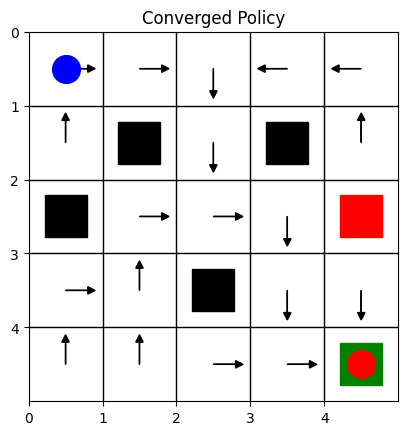

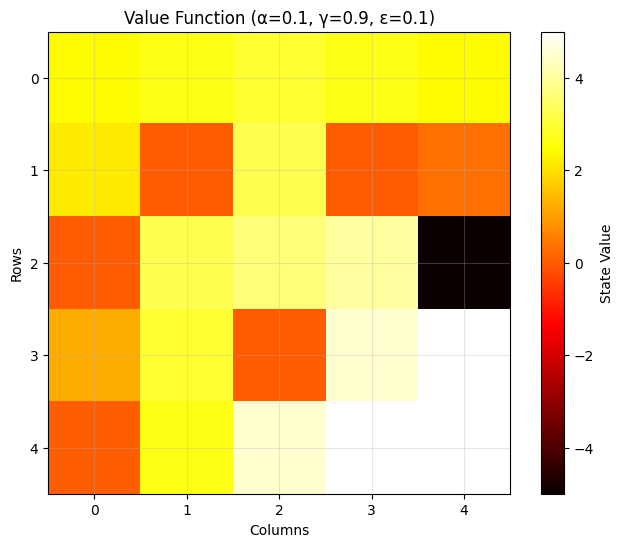

(array([[2, 2, 1, 3, 3],
        [0, 1, 1, 1, 0],
        [0, 2, 2, 1, 2],
        [2, 0, 0, 1, 1],
        [0, 0, 2, 2, 0]]),
 array([[ 2.39184194e+00,  2.65760216e+00,  2.95289129e+00,
          2.65760216e+00,  2.39137148e+00],
        [ 2.15265775e+00,  7.01071173e-04,  3.28099032e+00,
          9.28892828e-04,  3.37265563e-01],
        [ 9.66465666e-04,  3.28099032e+00,  3.64554480e+00,
          4.05060533e+00, -5.00000000e+00],
        [ 1.24698937e+00,  2.95289126e+00,  9.75595533e-04,
          4.50067259e+00,  5.00074733e+00],
        [ 4.63448333e-02,  2.65736671e+00,  4.50067259e+00,
          5.00074733e+00,  5.00000000e+00]]))

In [4]:
grid_config = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 5],
    'obstacle_states': [[3, 1], [2, 2], [2, 4], [4, 3]],
    'trap_state': [3, 5],
    'seed': 27
}

env = GridWorld(
                    size=grid_config['size'],
                    start=grid_config['start'],
                    goal_state=grid_config['goal_state'],
                    obstacle_states=grid_config['obstacle_states'],
                    trap_state=grid_config['trap_state'],
                    seed=grid_config['seed']
                )


agent1 = Qlearning(env, alpha=0.1, episodes=100000, seed=27, gamma=0.9, epsilon=0.1)
agent1.train(verbose=True)  # Train the agent first!
agent1.plot_policy_and_value()

In [5]:
agent1.get_training_statistics()

{'total_episodes': 100000,
 'goal_episodes': 97134,
 'trap_episodes': 2865,
 'timeout_episodes': 1,
 'success_rate': 0.97134,
 'trap_rate': 0.02865,
 'timeout_rate': 1e-05,
 'failure_rate': 0.02866,
 'avg_steps': np.float64(8.87437),
 'avg_reward': np.float64(4.57388),
 'total_steps': 887437,
 'total_reward': 457388}

### Q2 - Do it for A = 0.1, 0.5 and 0.9, take Epsilon = 0.1.

Starting Q-learning training...
Episodes: 100000, Learning Rate: 0.1
Discount Factor: 0.1, Epsilon: 0.1
------------------------------------------------------------
------------------------------------------------------------
Training completed!


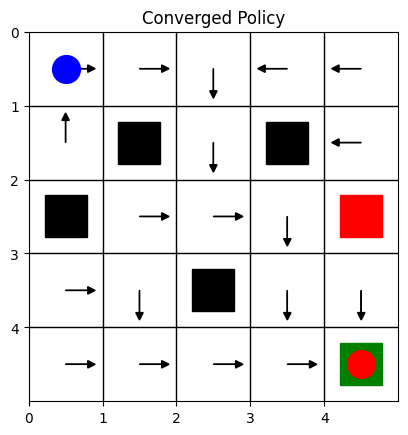

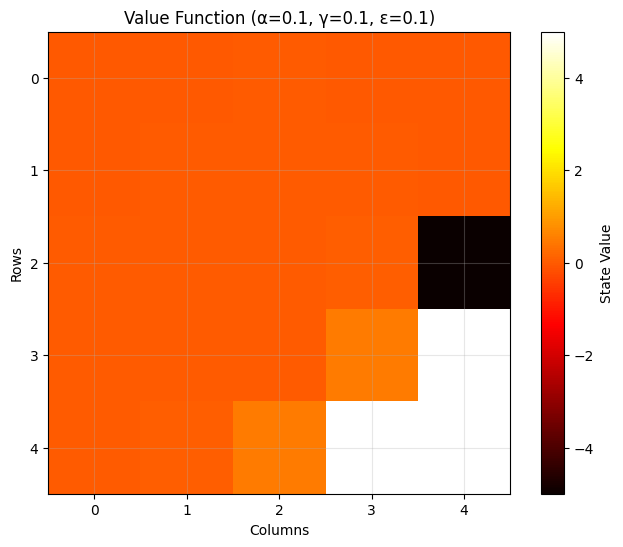

{'total_episodes': 100000, 'goal_episodes': 97124, 'trap_episodes': 2876, 'timeout_episodes': 0, 'success_rate': 0.97124, 'trap_rate': 0.02876, 'timeout_rate': 0.0, 'failure_rate': 0.02876, 'avg_steps': np.float64(8.87012), 'avg_reward': np.float64(4.57241), 'total_steps': 887012, 'total_reward': 457241}
Starting Q-learning training...
Episodes: 100000, Learning Rate: 0.1
Discount Factor: 0.5, Epsilon: 0.1
------------------------------------------------------------
------------------------------------------------------------
Training completed!


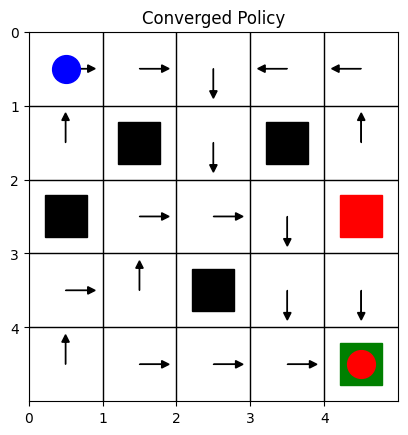

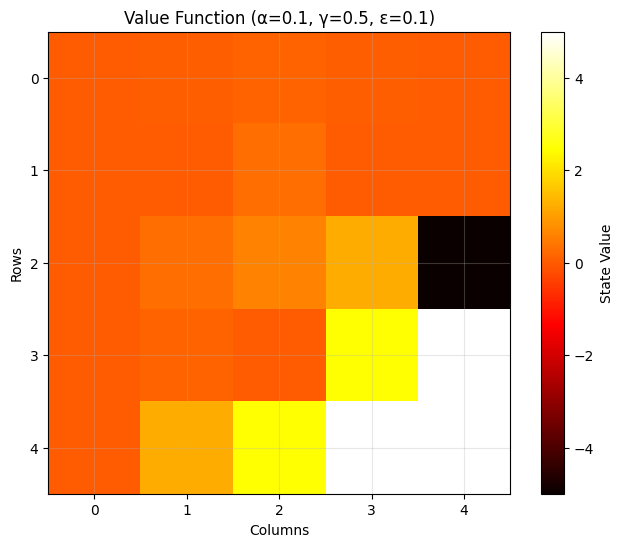

{'total_episodes': 100000, 'goal_episodes': 97132, 'trap_episodes': 2867, 'timeout_episodes': 1, 'success_rate': 0.97132, 'trap_rate': 0.02867, 'timeout_rate': 1e-05, 'failure_rate': 0.02868, 'avg_steps': np.float64(8.866), 'avg_reward': np.float64(4.57348), 'total_steps': 886600, 'total_reward': 457348}
Starting Q-learning training...
Episodes: 100000, Learning Rate: 0.1
Discount Factor: 0.9, Epsilon: 0.1
------------------------------------------------------------
------------------------------------------------------------
Training completed!


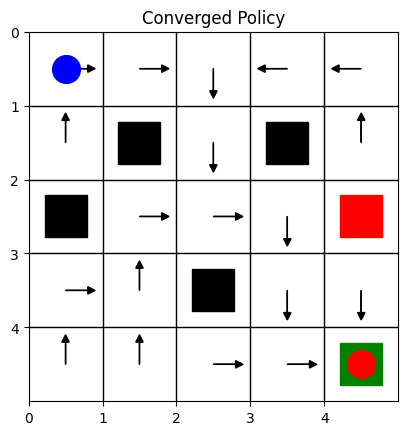

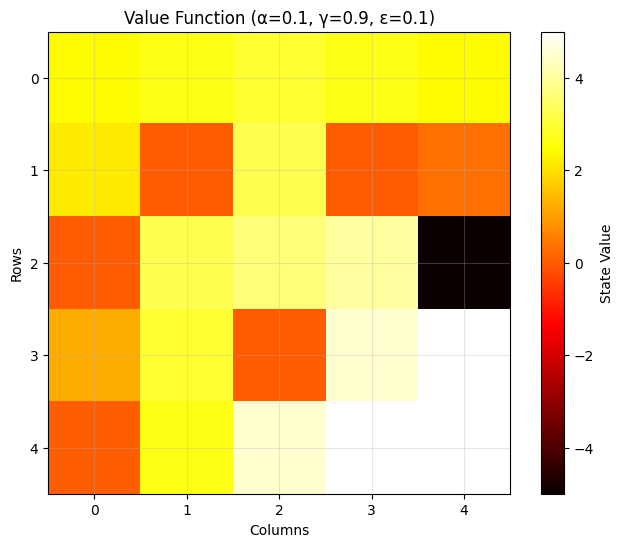

{'total_episodes': 100000, 'goal_episodes': 97134, 'trap_episodes': 2865, 'timeout_episodes': 1, 'success_rate': 0.97134, 'trap_rate': 0.02865, 'timeout_rate': 1e-05, 'failure_rate': 0.02866, 'avg_steps': np.float64(8.87437), 'avg_reward': np.float64(4.57388), 'total_steps': 887437, 'total_reward': 457388}


In [6]:
grid_config = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 5],
    'obstacle_states': [[3, 1], [2, 2], [2, 4], [4, 3]],
    'trap_state': [3, 5],
    'seed': 27
}

gammas = [0.1, 0.5, 0.9]

for gamma in gammas:

    env = GridWorld(
                        size=grid_config['size'],
                        start=grid_config['start'],
                        goal_state=grid_config['goal_state'],
                        obstacle_states=grid_config['obstacle_states'],
                        trap_state=grid_config['trap_state'],
                        seed=grid_config['seed']
                    )


    agent2 = Qlearning(env, alpha=0.1, episodes=100000, seed=27, gamma=gamma, epsilon=0.1)
    agent2.train(verbose=True)  # Train the agent first!
    agent2.plot_policy_and_value()
    print(agent2.get_training_statistics())

### Q3 - For gamma = 0.9, plot the no. of steps to reach the goal across episodes for epsilon = 0.1, 0.3 and 0.5.

In [14]:
print("=" * 70)
print("Average Steps / Rewards over Log Episodes")
print("=" * 70)

grid_config = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 5],
    'obstacle_states': [[3, 1], [2, 2], [2, 4], [4, 3]],
    'trap_state': [3, 5],
    'seed': 27
}

results_3 = Qlearning.run_multiple_epochs(
    env_config=grid_config,
    alpha=0.1,
    episodes=100000,
    gamma=0.9,
    epsilon_values=[0.1, 0.3, 0.5],
    num_epochs=20,
    verbose=True
)

print("\n" + "=" * 70)
print("EXPERIMENT COMPLETED - Generating Plots...")
print("=" * 70)

Qlearning.plot_epsilon_comparison(results_3, gamma=0.9, episodes=100000)

Average Steps / Rewards over Log Episodes

Training with ε = 0.1 (γ = 0.9)
Epoch 1/20... Done
Epoch 2/20... Done
Epoch 3/20... Done
Epoch 4/20... 

KeyboardInterrupt: 


GENERATING SEPARATE PLOTS FOR EACH EPSILON VALUE



GENERATING SEPARATE PLOTS FOR EACH EPSILON VALUE


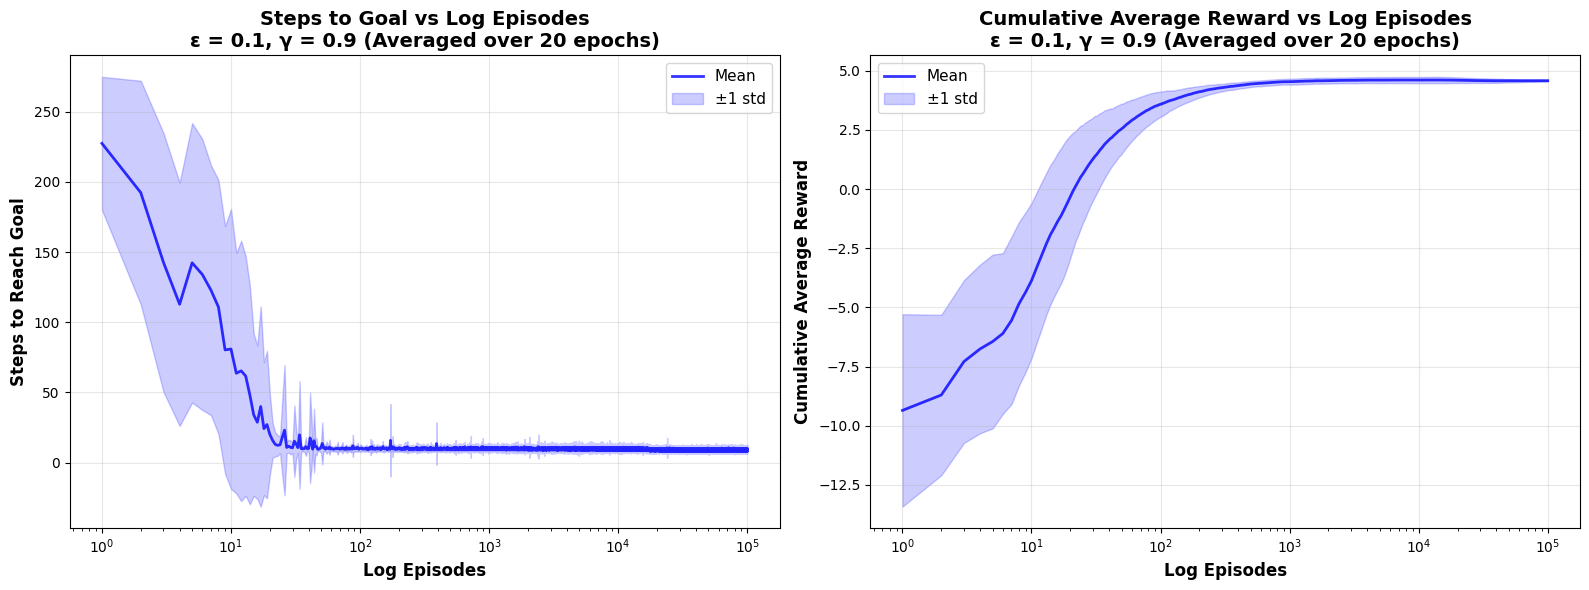


GENERATING SEPARATE PLOTS FOR EACH EPSILON VALUE


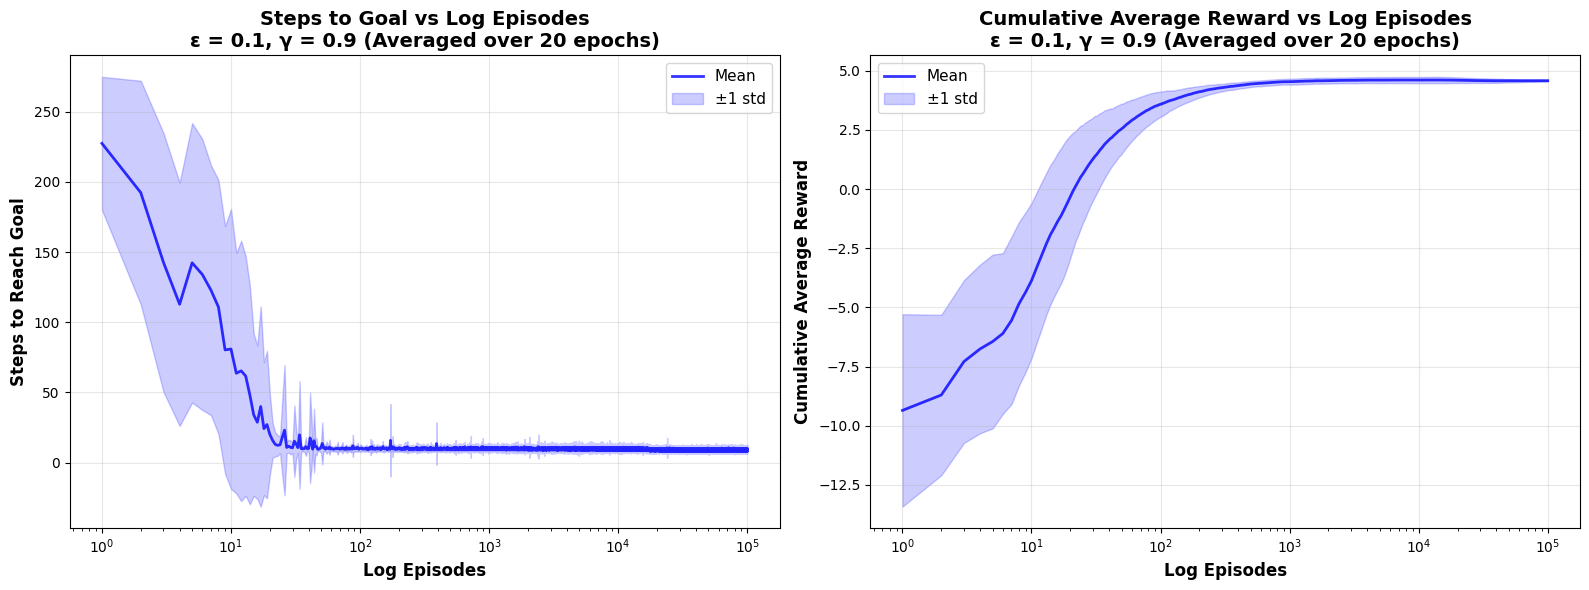


STATISTICS FOR ε = 0.1
Final Average Steps to Goal: 8.60 ± 1.36
Final Cumulative Avg Reward:  4.5816 ± 0.0377
Minimum Steps (across all episodes): 7.80
Maximum Cumulative Reward: 4.6121




GENERATING SEPARATE PLOTS FOR EACH EPSILON VALUE


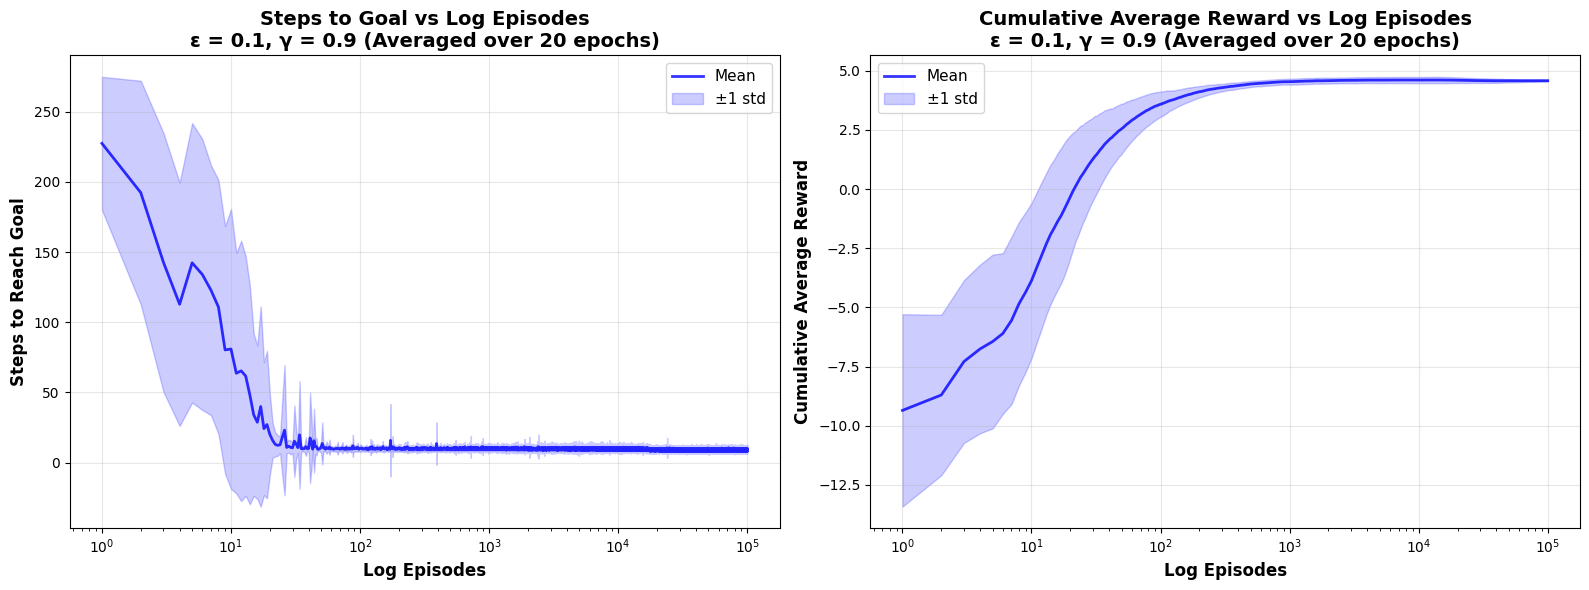


STATISTICS FOR ε = 0.1
Final Average Steps to Goal: 8.60 ± 1.36
Final Cumulative Avg Reward:  4.5816 ± 0.0377
Minimum Steps (across all episodes): 7.80
Maximum Cumulative Reward: 4.6121



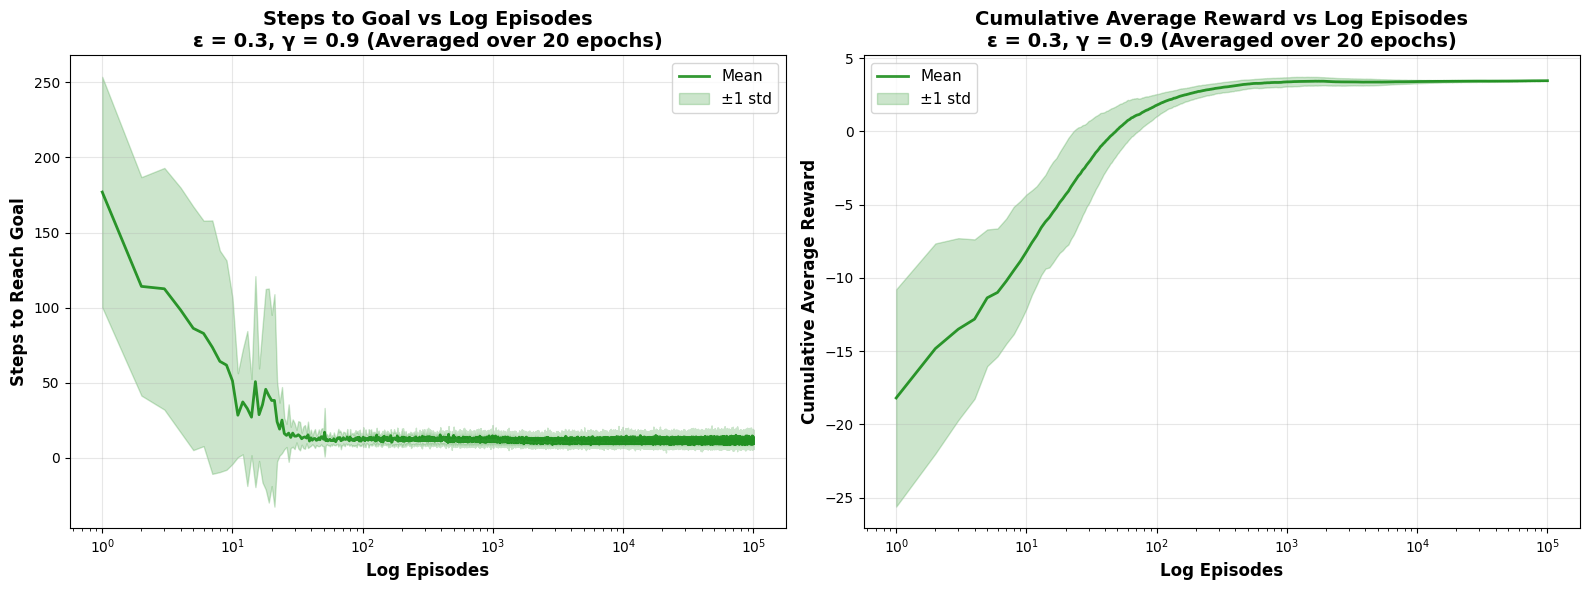


GENERATING SEPARATE PLOTS FOR EACH EPSILON VALUE


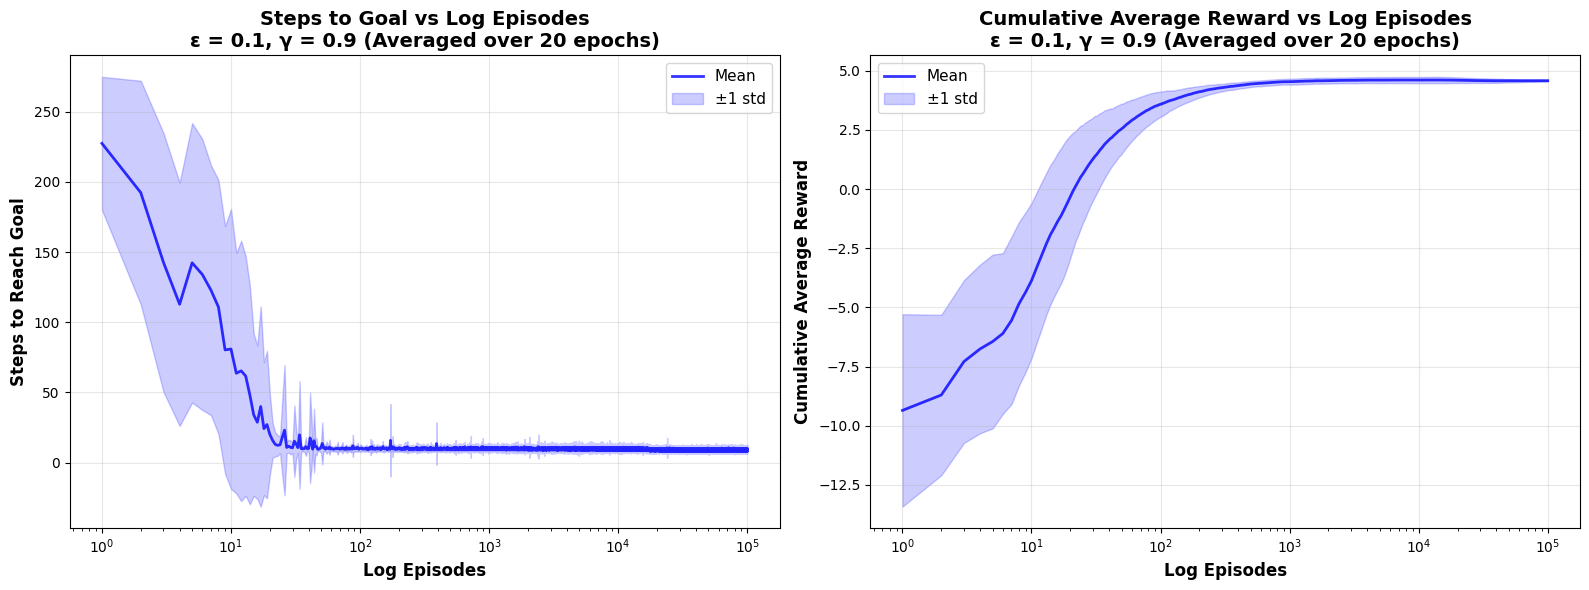


STATISTICS FOR ε = 0.1
Final Average Steps to Goal: 8.60 ± 1.36
Final Cumulative Avg Reward:  4.5816 ± 0.0377
Minimum Steps (across all episodes): 7.80
Maximum Cumulative Reward: 4.6121



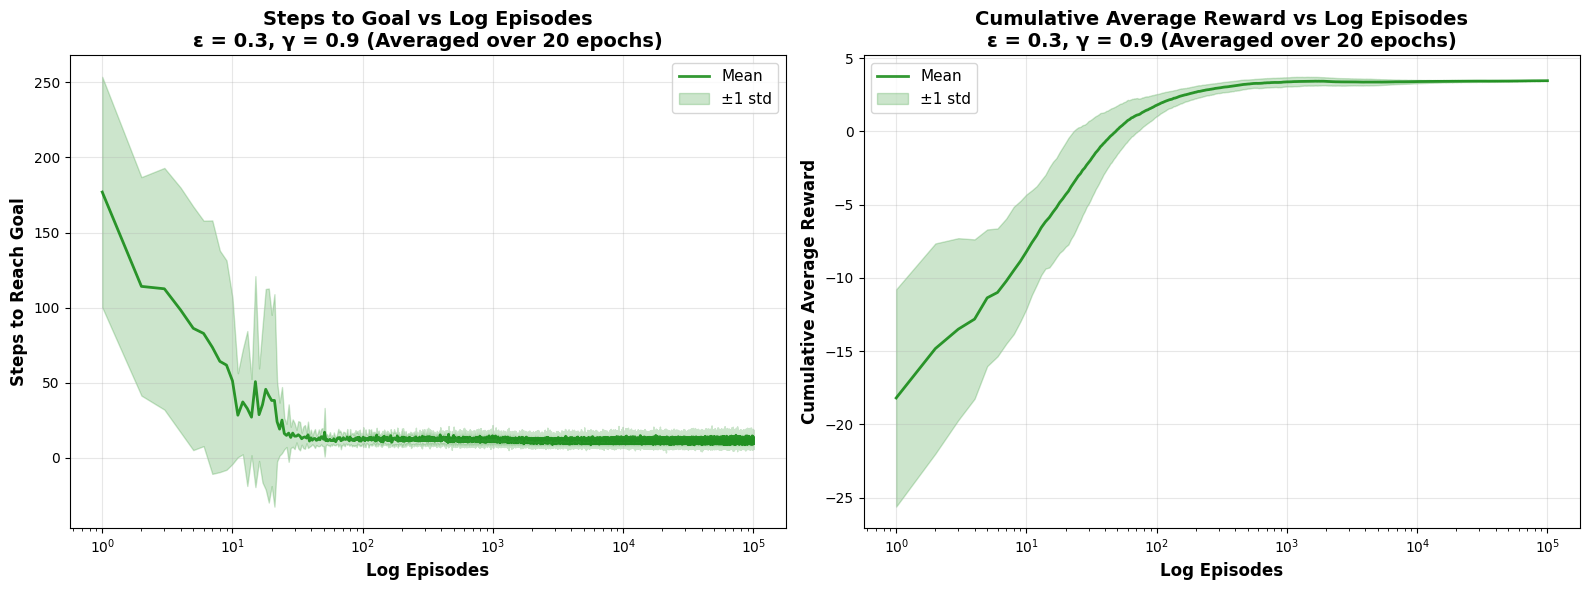


STATISTICS FOR ε = 0.3
Final Average Steps to Goal: 10.10 ± 2.43
Final Cumulative Avg Reward:  3.4691 ± 0.0234
Minimum Steps (across all episodes): 8.70
Maximum Cumulative Reward: 3.4691




GENERATING SEPARATE PLOTS FOR EACH EPSILON VALUE


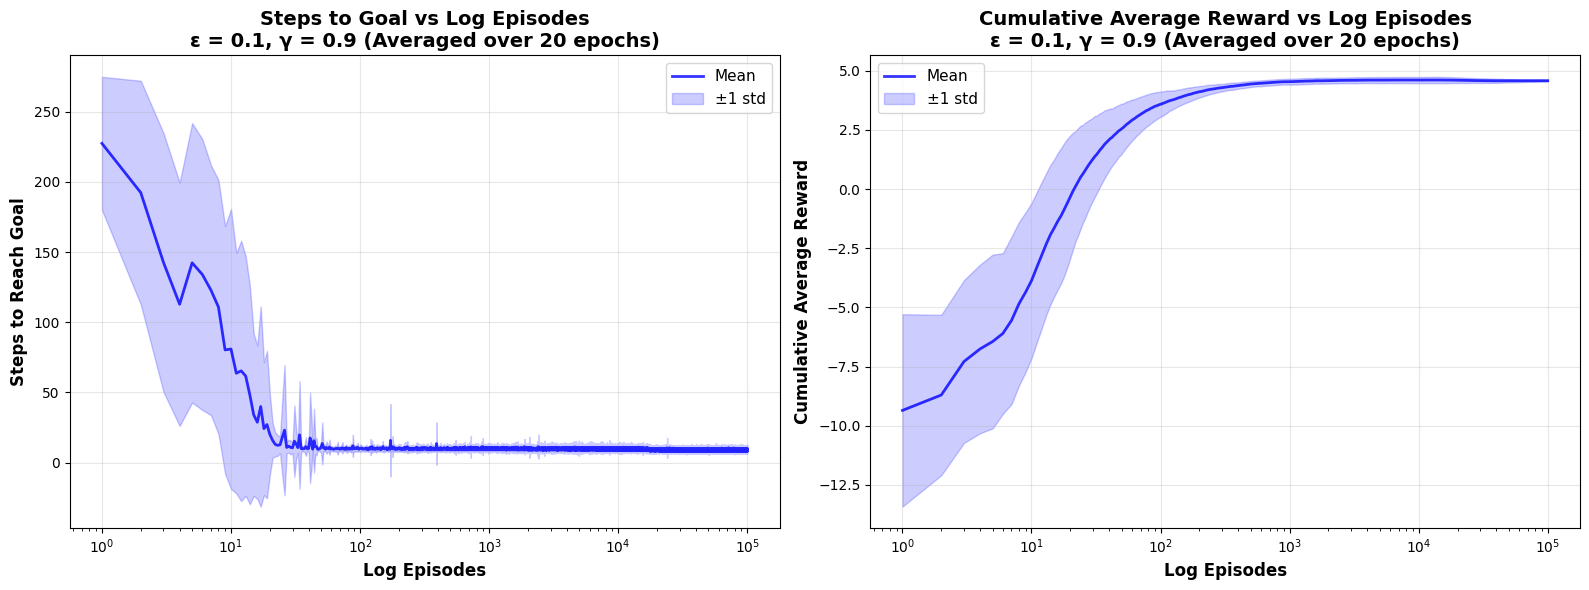


STATISTICS FOR ε = 0.1
Final Average Steps to Goal: 8.60 ± 1.36
Final Cumulative Avg Reward:  4.5816 ± 0.0377
Minimum Steps (across all episodes): 7.80
Maximum Cumulative Reward: 4.6121



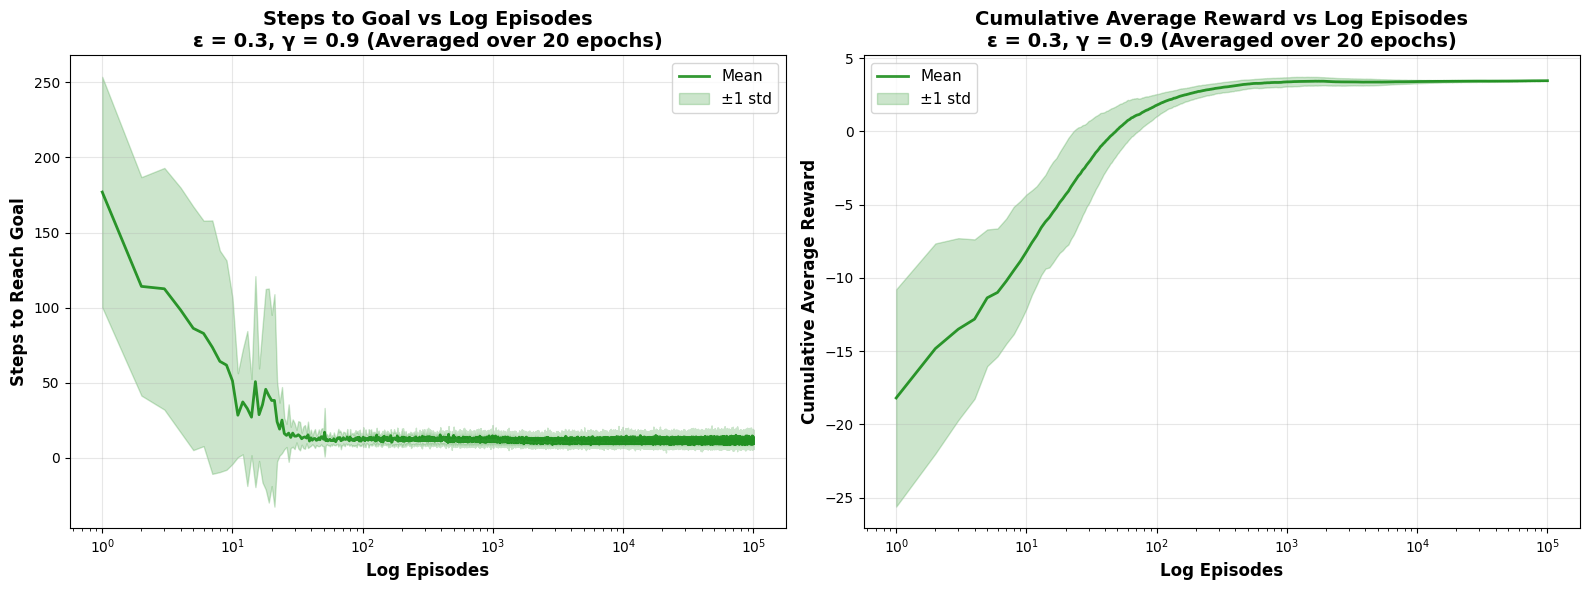


STATISTICS FOR ε = 0.3
Final Average Steps to Goal: 10.10 ± 2.43
Final Cumulative Avg Reward:  3.4691 ± 0.0234
Minimum Steps (across all episodes): 8.70
Maximum Cumulative Reward: 3.4691



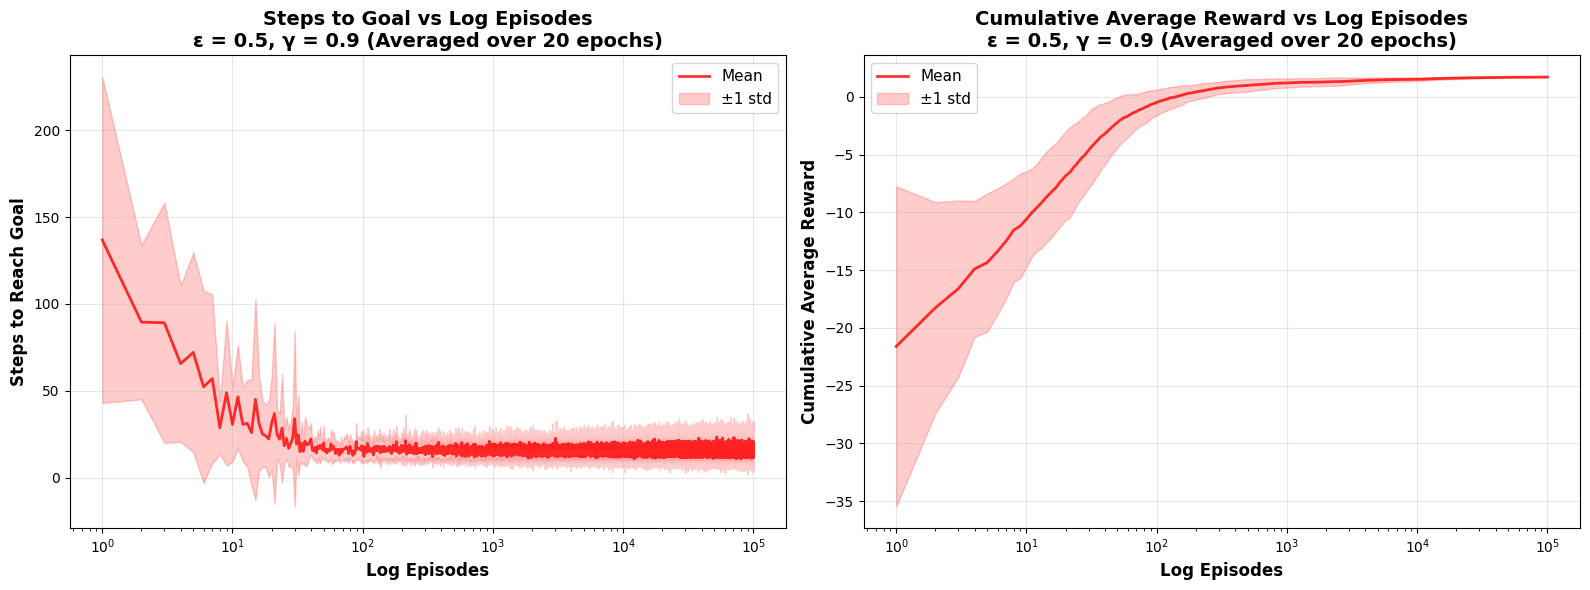


STATISTICS FOR ε = 0.5
Final Average Steps to Goal: 15.65 ± 7.62
Final Cumulative Avg Reward:  1.7194 ± 0.0170
Minimum Steps (across all episodes): 10.80
Maximum Cumulative Reward: 1.7194



In [ ]:
print("\n" + "=" * 70)
print("GENERATING SEPARATE PLOTS FOR EACH EPSILON VALUE")
print("=" * 70)

Qlearning.plot_epsilon_separate(results_3, gamma=0.9, episodes=100000)

### Q3 - Alternative: Segregated Runs Per Epsilon Value

This section provides individual training runs for each epsilon value, allowing for detailed analysis of each configuration separately.

In [ ]:
# Segregated Experiment Flow Overview
print("=" * 80)
print(" " * 20 + "SEGREGATED EPSILON EXPERIMENTS FLOW")
print("=" * 80)
print()
print("This section runs THREE separate experiments, one for each epsilon value:")
print()
print(f"  📊 Experiment 1: ε = 0.1 (Low Exploration)")
print(f"     ├─ Train: {NUM_EPOCHS} epochs × {NUM_EPISODES:,} episodes")
print(f"     ├─ Analyze: Steps to goal & cumulative reward")
print(f"     └─ Visualize: Individual plots with std deviation")
print()
print(f"  📊 Experiment 2: ε = 0.3 (Moderate Exploration)")
print(f"     ├─ Train: {NUM_EPOCHS} epochs × {NUM_EPISODES:,} episodes")
print(f"     ├─ Analyze: Steps to goal & cumulative reward")
print(f"     └─ Visualize: Individual plots with std deviation")
print()
print(f"  📊 Experiment 3: ε = 0.5 (High Exploration)")
print(f"     ├─ Train: {NUM_EPOCHS} epochs × {NUM_EPISODES:,} episodes")
print(f"     ├─ Analyze: Steps to goal & cumulative reward")
print(f"     └─ Visualize: Individual plots with std deviation")
print()
print(f"  📈 Final Comparison:")
print(f"     ├─ Combined visualization of all epsilon values")
print(f"     └─ Summary statistics table with best performers")
print()
print("=" * 80)
print(f"Configuration: α = {ALPHA}, γ = {GAMMA}, Grid Size = {grid_config['size']}×{grid_config['size']}")
print("=" * 80)

#### Configuration Parameters

Set the number of epochs and episodes for all experiments below:

In [ ]:
# =============================================================================
# CONFIGURATION PARAMETERS - Adjust these values as needed
# =============================================================================

# Number of epochs (independent runs) for averaging results
NUM_EPOCHS = 20  # Default: 20, can be changed to 5, 10, 30, etc.

# Number of episodes per epoch
NUM_EPISODES = 100000  # Default: 100000, can be reduced for faster testing

# Grid configuration
grid_config = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 5],
    'obstacle_states': [[3, 1], [2, 2], [2, 4], [4, 3]],
    'trap_state': [3, 5],
    'seed': 27
}

# Learning parameters
ALPHA = 0.1   # Learning rate
GAMMA = 0.9   # Discount factor

# Epsilon values to test
EPSILON_VALUES = [0.1, 0.3, 0.5]

print("=" * 80)
print("CONFIGURATION LOADED")
print("=" * 80)
print(f"📊 Number of Epochs: {NUM_EPOCHS}")
print(f"📈 Episodes per Epoch: {NUM_EPISODES}")
print(f"🎯 Learning Rate (α): {ALPHA}")
print(f"💰 Discount Factor (γ): {GAMMA}")
print(f"🔍 Epsilon Values: {EPSILON_VALUES}")
print(f"🗺️  Grid Size: {grid_config['size']}×{grid_config['size']}")
print("=" * 80)

**💡 Quick Configuration Guide:**

- **For Quick Testing:** Set `NUM_EPOCHS = 5` and `NUM_EPISODES = 10000`
- **For Standard Results:** Set `NUM_EPOCHS = 20` and `NUM_EPISODES = 100000` (default)
- **For High Precision:** Set `NUM_EPOCHS = 50` and `NUM_EPISODES = 200000`

Simply modify the values in the cell below and run all subsequent cells!

#### Run 1: Epsilon = 0.1

In [ ]:
print("=" * 70)
print("Training with Epsilon = 0.1")
print("=" * 70)
print(f"Epochs: {NUM_EPOCHS} | Episodes per Epoch: {NUM_EPISODES:,}")
print("=" * 70)

# Run multiple epochs for epsilon = 0.1
results_eps_01 = Qlearning.run_multiple_epochs(
    env_config=grid_config,
    alpha=ALPHA,
    episodes=NUM_EPISODES,
    gamma=GAMMA,
    epsilon_values=[0.1],
    num_epochs=NUM_EPOCHS,
    verbose=True
)

print("\n" + "=" * 70)
print("Training Completed for ε = 0.1")
print("=" * 70)

In [ ]:
# Plot results for epsilon = 0.1
print("Generating plots for ε = 0.1...")
Qlearning.plot_epsilon_separate(results_eps_01, gamma=GAMMA, episodes=NUM_EPISODES)

#### Run 2: Epsilon = 0.3

In [ ]:
print("=" * 70)
print("Training with Epsilon = 0.3")
print("=" * 70)
print(f"Epochs: {NUM_EPOCHS} | Episodes per Epoch: {NUM_EPISODES:,}")
print("=" * 70)

# Run multiple epochs for epsilon = 0.3
results_eps_03 = Qlearning.run_multiple_epochs(
    env_config=grid_config,
    alpha=ALPHA,
    episodes=NUM_EPISODES,
    gamma=GAMMA,
    epsilon_values=[0.3],
    num_epochs=NUM_EPOCHS,
    verbose=True
)

print("\n" + "=" * 70)
print("Training Completed for ε = 0.3")
print("=" * 70)

In [ ]:
# Plot results for epsilon = 0.3
print("Generating plots for ε = 0.3...")
Qlearning.plot_epsilon_separate(results_eps_03, gamma=GAMMA, episodes=NUM_EPISODES)

#### Run 3: Epsilon = 0.5

In [ ]:
print("=" * 70)
print("Training with Epsilon = 0.5")
print("=" * 70)
print(f"Epochs: {NUM_EPOCHS} | Episodes per Epoch: {NUM_EPISODES:,}")
print("=" * 70)

# Run multiple epochs for epsilon = 0.5
results_eps_05 = Qlearning.run_multiple_epochs(
    env_config=grid_config,
    alpha=ALPHA,
    episodes=NUM_EPISODES,
    gamma=GAMMA,
    epsilon_values=[0.5],
    num_epochs=NUM_EPOCHS,
    verbose=True
)

print("\n" + "=" * 70)
print("Training Completed for ε = 0.5")
print("=" * 70)

In [ ]:
# Plot results for epsilon = 0.5
print("Generating plots for ε = 0.5...")
Qlearning.plot_epsilon_separate(results_eps_05, gamma=GAMMA, episodes=NUM_EPISODES)

#### Comparison Across All Epsilon Values

In [ ]:
# Combine all results for comparison
print("=" * 70)
print("COMBINED COMPARISON OF ALL EPSILON VALUES")
print("=" * 70)

combined_results = {
    0.1: results_eps_01[0.1],
    0.3: results_eps_03[0.3],
    0.5: results_eps_05[0.5]
}

# Plot combined comparison
Qlearning.plot_epsilon_comparison(combined_results, gamma=GAMMA, episodes=NUM_EPISODES)

#### Summary Statistics for All Epsilon Values

In [ ]:
import pandas as pd

# Create summary statistics table
summary_data = []

for epsilon, results in combined_results.items():
    summary_data.append({
        'Epsilon (ε)': epsilon,
        'Final Avg Steps': f"{results['avg_steps'][-1]:.2f}",
        'Steps Std Dev': f"{results['std_steps'][-1]:.2f}",
        'Min Steps (All Episodes)': f"{np.min(results['avg_steps']):.2f}",
        'Final Cumulative Avg Reward': f"{results['cumulative_avg_reward'][-1]:.4f}",
        'Reward Std Dev': f"{results['std_cumulative_avg_reward'][-1]:.4f}",
        'Max Cumulative Reward': f"{np.max(results['cumulative_avg_reward']):.4f}"
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "=" * 100)
print(f"SUMMARY STATISTICS FOR ALL EPSILON VALUES (γ = {GAMMA}, {NUM_EPOCHS} Epochs)")
print("=" * 100)
print(summary_df.to_string(index=False))
print("=" * 100)

# Determine best epsilon
best_reward_idx = np.argmax([results['cumulative_avg_reward'][-1] for results in combined_results.values()])
best_steps_idx = np.argmin([results['avg_steps'][-1] for results in combined_results.values()])
epsilon_list = list(combined_results.keys())

print(f"\n✓ Best ε for Reward: {epsilon_list[best_reward_idx]}")
print(f"✓ Best ε for Steps: {epsilon_list[best_steps_idx]}")
print("=" * 100 + "\n")

---

### 🎯 Key Insights and Observations

Based on the segregated runs, you can now analyze:
- **Exploration vs Exploitation Trade-off**: Compare how different ε values balance exploration and exploitation
- **Convergence Speed**: Which ε value leads to faster convergence?
- **Stability**: Which ε value produces more consistent results (lower std deviation)?
- **Final Performance**: Which ε achieves the best cumulative reward and minimum steps?

Each epsilon value creates a different learning behavior:
- **ε = 0.1**: More exploitation, faster convergence but may miss optimal paths
- **ε = 0.3**: Balanced approach with moderate exploration
- **ε = 0.5**: High exploration, more robust but slower convergence

## Part 2

### Q1 - Plot the converged policy and value function for this grid world. Use softmax function for action selection.

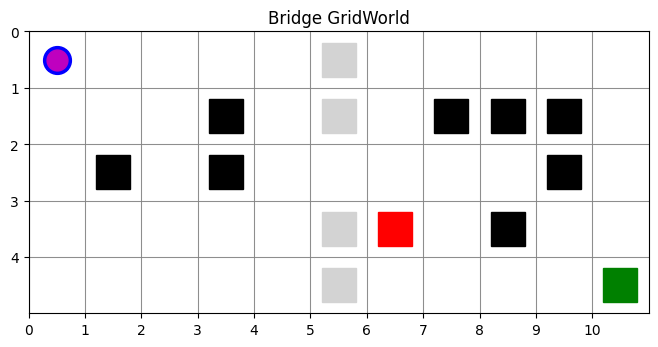

In [11]:
# Bridge setup based on your image
bridge_state = [3, 6]
bridge_connection = {'left': [3, 5], 'right': [3, 7]}

# Example obstacles from the image (you can fill exact coordinates)
obstacles = [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]]

env = BridgeGridWorld(
    size=5,
    start=[1, 1],
    goal_state=[5, 11],
    obstacle_states=obstacles,
    trap_state=[4, 7],
    seed=42,
    bridge_state=bridge_state
)

env.reset()
env.plot_grid()


Starting Q-learning training...
Episodes: 2000, Learning Rate: 0.1
Discount Factor: 0.9, Epsilon: 0.1
------------------------------------------------------------
------------------------------------------------------------
Training completed!


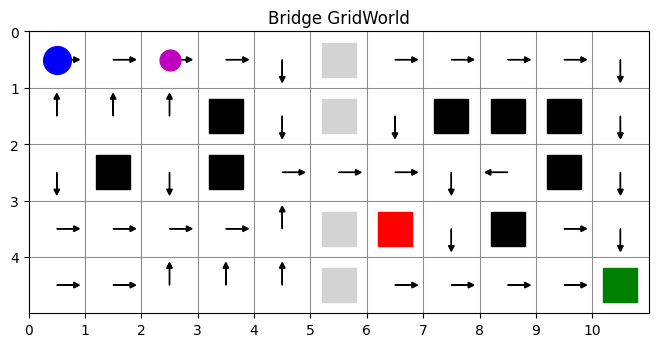

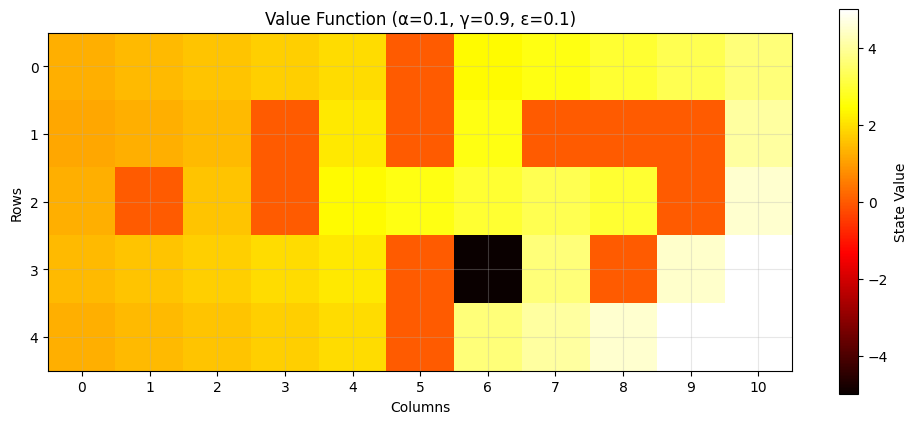

(array([[2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 1],
        [0, 0, 0, 2, 1, 2, 1, 1, 1, 1, 1],
        [1, 1, 1, 0, 2, 2, 2, 1, 3, 2, 1],
        [2, 2, 2, 2, 0, 2, 0, 1, 2, 2, 1],
        [2, 2, 0, 0, 0, 0, 2, 2, 2, 2, 3]]),
 array([[ 1.26615495e+00,  1.40691270e+00,  1.56329161e+00,
          1.73710104e+00,  1.93028636e+00,  7.83289802e-04,
          2.38816216e+00,  2.65443650e+00,  2.94987461e+00,
          3.27799185e+00,  3.64291724e+00],
        [ 1.13943162e+00,  1.26614590e+00,  1.40689030e+00,
          9.91710897e-04,  2.14501603e+00,  9.10535370e-04,
          2.64790422e+00,  8.69542857e-04,  3.93213956e-04,
          9.80703014e-04,  4.04892970e+00],
        [ 1.26598727e+00,  9.82805034e-04,  1.56326814e+00,
          9.42747804e-04,  2.38350218e+00,  2.64866152e+00,
          2.94348518e+00,  3.27138092e+00,  2.94288714e+00,
          6.31223626e-04,  4.49972507e+00],
        [ 1.40674756e+00,  1.56325384e+00,  1.73714367e+00,
          1.93038573e+00,  2.14500701e+00,  6.69784

In [13]:
bridge_state = [3, 6]

obstacles = [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]]

env = BridgeGridWorld(
    size=5,
    start=[1, 1],
    goal_state=[5, 11],
    obstacle_states=obstacles,
    trap_state=[4, 7],
    seed=42,
    bridge_state=bridge_state
)

agent_b = Qlearning(env, alpha=0.1, episodes=2000, seed=27, gamma=0.9, epsilon=0.1)
agent_b.train(verbose=True, softmax=True)
agent_b.plot_policy_and_value()

In [10]:
agent_b.get_training_statistics()

{'total_episodes': 200,
 'goal_episodes': 11,
 'trap_episodes': 72,
 'timeout_episodes': 117,
 'success_rate': 0.055,
 'trap_rate': 0.36,
 'timeout_rate': 0.585,
 'failure_rate': 0.945,
 'avg_steps': np.float64(205.105),
 'avg_reward': np.float64(-44.34),
 'total_steps': 41021,
 'total_reward': -8868}

### Q2 - Do it for A = 0.1, 0.5 and 0.9, take beta = 0.1.

Starting Q-learning training...
Episodes: 200, Learning Rate: 0.1
Discount Factor: 0.1, Epsilon: 0.1
------------------------------------------------------------
------------------------------------------------------------
Training completed!


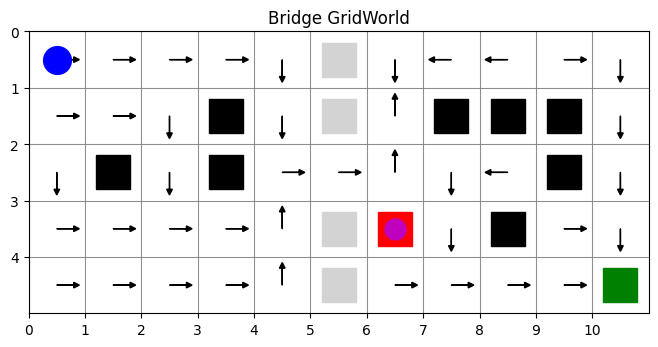

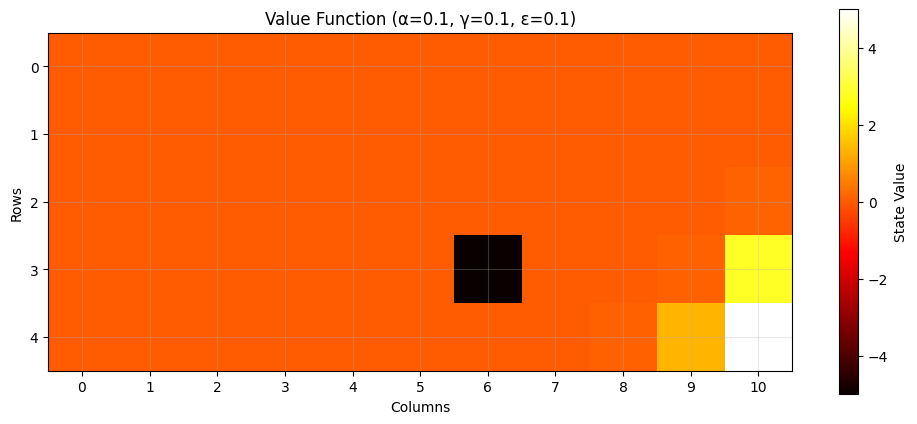

{'total_episodes': 200, 'goal_episodes': 11, 'trap_episodes': 72, 'timeout_episodes': 117, 'success_rate': 0.055, 'trap_rate': 0.36, 'timeout_rate': 0.585, 'failure_rate': 0.945, 'avg_steps': np.float64(205.105), 'avg_reward': np.float64(-44.365), 'total_steps': 41021, 'total_reward': -8873}
Starting Q-learning training...
Episodes: 200, Learning Rate: 0.1
Discount Factor: 0.5, Epsilon: 0.1
------------------------------------------------------------
------------------------------------------------------------
Training completed!


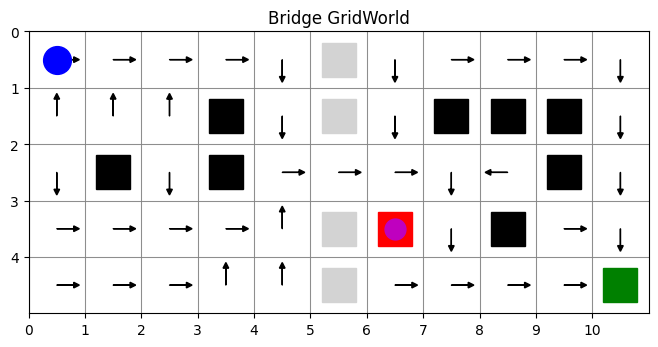

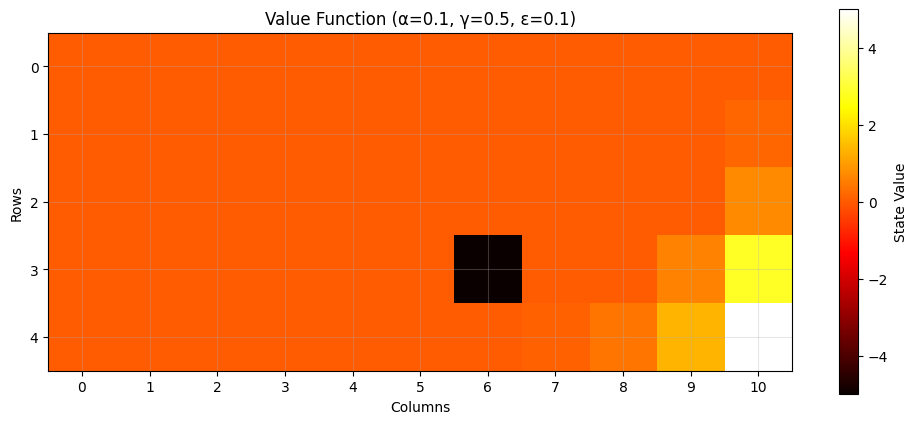

{'total_episodes': 200, 'goal_episodes': 11, 'trap_episodes': 72, 'timeout_episodes': 117, 'success_rate': 0.055, 'trap_rate': 0.36, 'timeout_rate': 0.585, 'failure_rate': 0.945, 'avg_steps': np.float64(205.105), 'avg_reward': np.float64(-44.34), 'total_steps': 41021, 'total_reward': -8868}
Starting Q-learning training...
Episodes: 200, Learning Rate: 0.1
Discount Factor: 0.9, Epsilon: 0.1
------------------------------------------------------------
------------------------------------------------------------
Training completed!


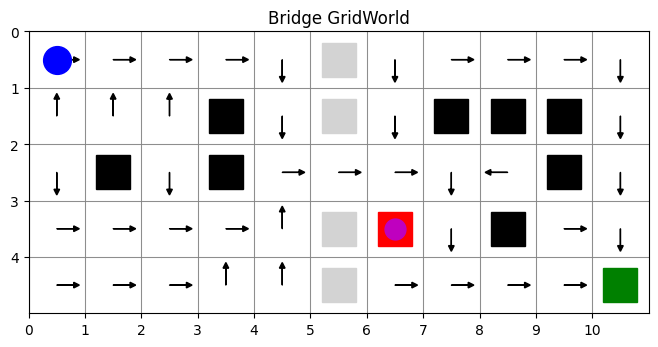

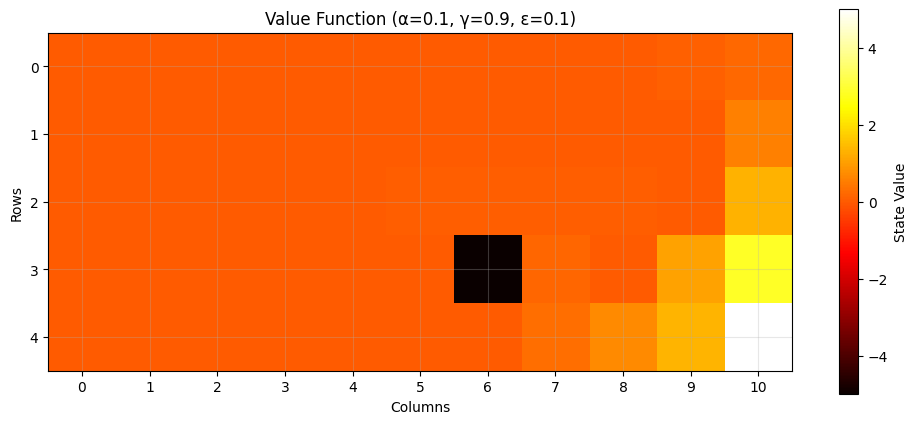

{'total_episodes': 200, 'goal_episodes': 11, 'trap_episodes': 72, 'timeout_episodes': 117, 'success_rate': 0.055, 'trap_rate': 0.36, 'timeout_rate': 0.585, 'failure_rate': 0.945, 'avg_steps': np.float64(205.105), 'avg_reward': np.float64(-44.34), 'total_steps': 41021, 'total_reward': -8868}


In [12]:
bridge_state = [3, 6]

obstacles = [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]]

gammas = [0.1, 0.5, 0.9]

for gamma in gammas:

    env = BridgeGridWorld(
    size=5,
    start=[1, 1],
    goal_state=[5, 11],
    obstacle_states=obstacles,
    trap_state=[4, 7],
    seed=42,
    bridge_state=bridge_state
    )
    
    bridgeAgent2 = Qlearning(env, alpha=0.1, episodes=200, seed=27, gamma=gamma, epsilon=0.1)
    bridgeAgent2.train(verbose=True, softmax=True)
    bridgeAgent2.plot_policy_and_value()
    print(bridgeAgent2.get_training_statistics())

### Q3 - For gamma = 0.9, plot the no. of steps to reach the goal across episodes for beta/epsilon = 0.1, 0.3 and 0.5.

In [ ]:
print("=" * 70)
print("BridgeGridWorld - Average Steps / Rewards over Log Episodes (Softmax)")
print("=" * 70)

bridge_config = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 11],
    'obstacle_states': [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]],
    'trap_state': [4, 7],
    'seed': 42,
    'bridge_state': [3, 6]
}

results_bridge_q3 = Qlearning.run_multiple_epochs_bridge(
    bridge_config=bridge_config,
    alpha=0.1,
    episodes=200000,
    gamma=0.9,
    epsilon_values=[0.1, 0.3, 0.5],
    num_epochs=20,
    verbose=True
)

print("\n" + "=" * 70)
print("EXPERIMENT COMPLETED - Generating Plots...")
print("=" * 70)

Qlearning.plot_epsilon_comparison(results_bridge_q3, gamma=0.9, episodes=200000)

BridgeGridWorld - Average Steps / Rewards over Log Episodes (Softmax)

Training BridgeGridWorld with β/ε = 0.1 (γ = 0.9)
Epoch 1/20... Done
Epoch 2/20... Done
Epoch 3/20... Done
Epoch 4/20... Done
Epoch 5/20... Done
Epoch 6/20... Done
Epoch 7/20... Done
Epoch 8/20... Done
Epoch 9/20... Done
Epoch 10/20... Done
Epoch 11/20... Done
Epoch 12/20... Done
Epoch 13/20... Done
Epoch 14/20... Done
Epoch 15/20... Done
Epoch 16/20... Done
Epoch 17/20... Done
Epoch 18/20... Done
Epoch 19/20... Done
Epoch 20/20... Done
Completed β/ε = 0.1

Training BridgeGridWorld with β/ε = 0.3 (γ = 0.9)
Epoch 1/20... Done
Epoch 2/20... Done
Epoch 3/20... Done
Epoch 4/20... Done
Epoch 5/20... Done
Epoch 6/20... Done
Epoch 7/20... Done
Epoch 8/20... Done
Epoch 9/20... 


GENERATING SEPARATE PLOTS FOR EACH BETA/EPSILON VALUE


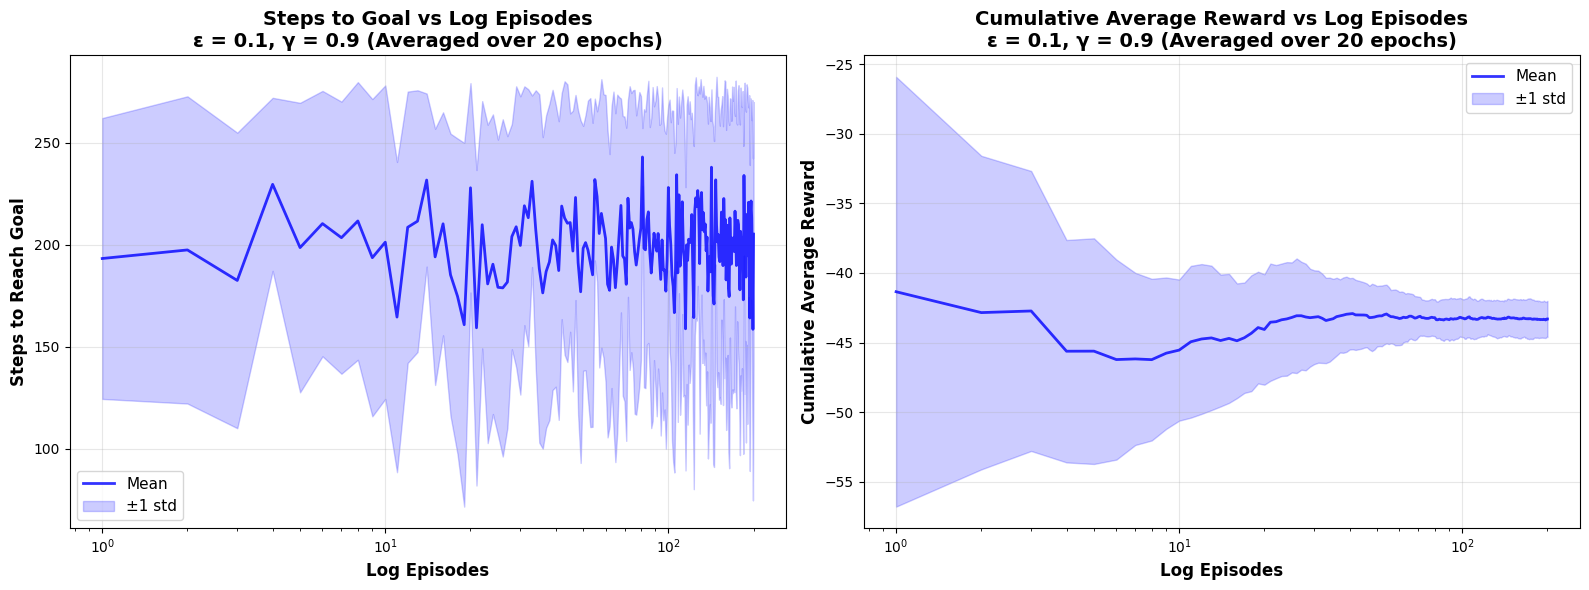


STATISTICS FOR ε = 0.1
Final Average Steps to Goal: 205.25 ± 64.74
Final Cumulative Avg Reward:  -43.3093 ± 1.3010
Minimum Steps (across all episodes): 158.60
Maximum Cumulative Reward: -41.3500



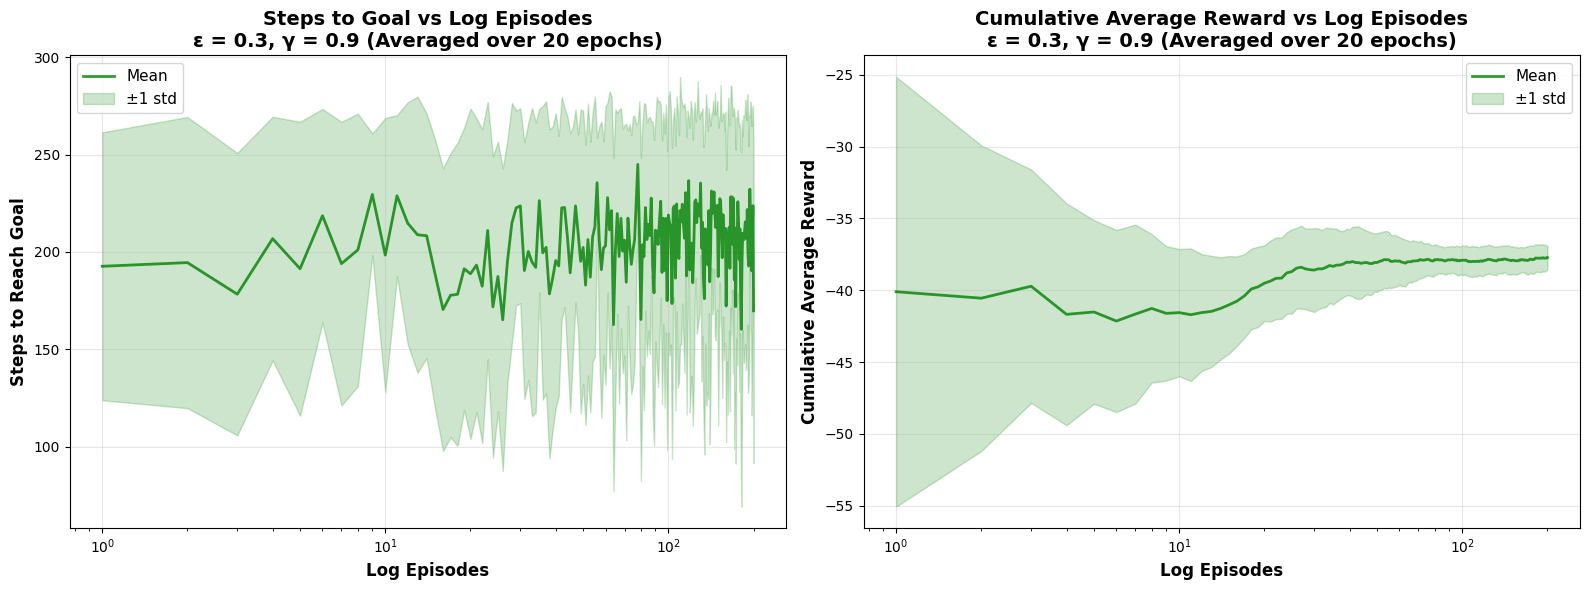


STATISTICS FOR ε = 0.3
Final Average Steps to Goal: 169.75 ± 78.34
Final Cumulative Avg Reward:  -37.7208 ± 0.8305
Minimum Steps (across all episodes): 160.25
Maximum Cumulative Reward: -37.7208



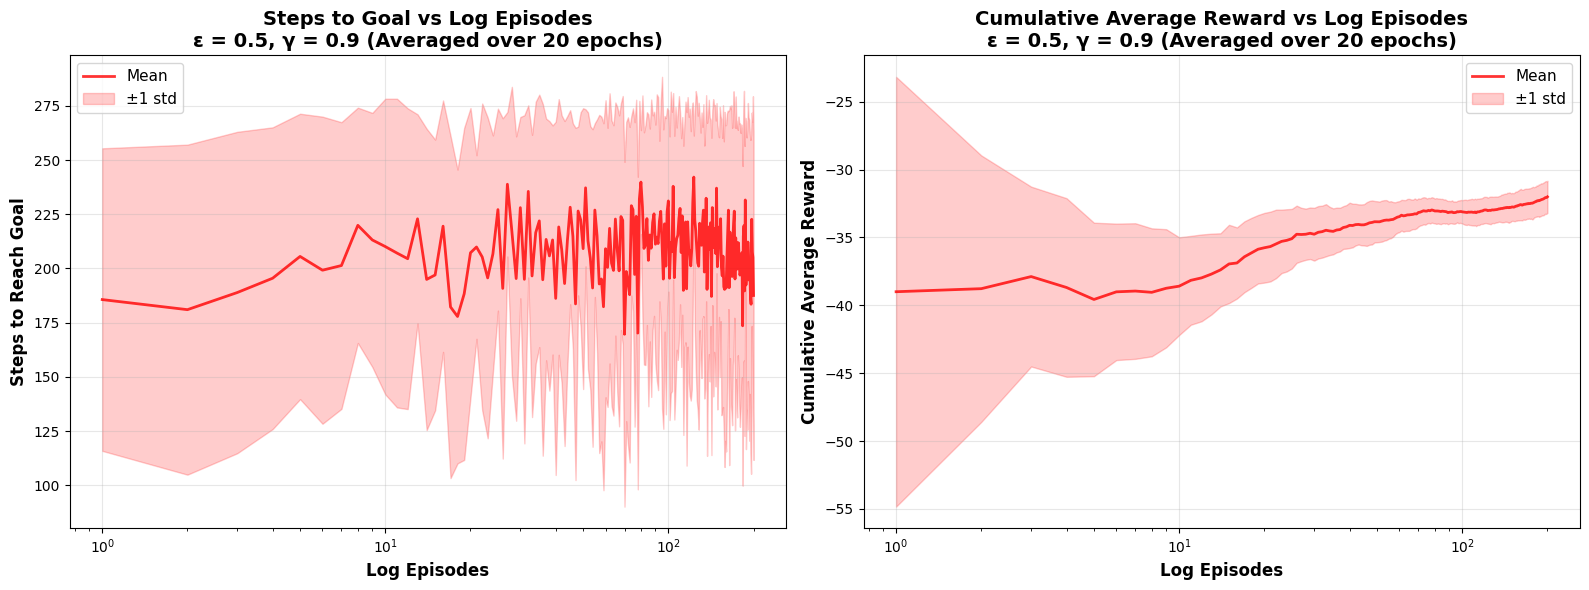


STATISTICS FOR ε = 0.5
Final Average Steps to Goal: 187.55 ± 75.84
Final Cumulative Avg Reward:  -32.0078 ± 1.1823
Minimum Steps (across all episodes): 169.65
Maximum Cumulative Reward: -32.0078



In [24]:
print("\n" + "=" * 70)
print("GENERATING SEPARATE PLOTS FOR EACH BETA/EPSILON VALUE")
print("=" * 70)

Qlearning.plot_epsilon_separate(results_bridge_q3, gamma=0.9, episodes=200000)

---
## 🚀 Speed Optimization Guide

### Why BridgeGridWorld is Slow:
1. **Long episodes**: `max_steps = 5 × 11 × 10 = 550` steps per episode
2. **Many timeouts**: Early training rarely reaches goal
3. **Total computation**: 200,000 episodes × ~300 avg steps = 60M+ steps!

### Applied Optimizations:
✅ **Reduced `max_steps` multiplier from 10 to 3** (165 steps max)
   - Optimal path: ~15-18 steps
   - With exploration: ~30-50 steps typical
   - Timeout at 165 gives ~3-5× safety margin

### Additional Speed Tips:
1. **Try fewer episodes first**: Test with 50,000-100,000 episodes
2. **Increase learning rate**: Try `alpha=0.2` or `0.3` for faster learning
3. **Start with single epoch**: Use `num_epochs=1` to test before full 20-epoch run
4. **Monitor early stopping**: Check if agent converges before 200k episodes

### Quick Test (Run This First):
```python
# Fast test with fewer episodes
results_test = Qlearning.run_multiple_epochs_bridge(
    bridge_config=bridge_config,
    alpha=0.2,  # Higher learning rate
    episodes=50000,  # 1/4 of full run
    gamma=0.9,
    epsilon_values=[0.1],  # Test just one epsilon
    num_epochs=1,  # Single epoch test
    verbose=True
)
```

Expected runtime with optimizations:
- **Before**: ~30-60 minutes per epoch
- **After**: ~5-10 minutes per epoch

### Quick Speed Test (Run This First!)

In [ ]:
import time

print("=" * 70)
print("QUICK SPEED TEST - Single Epoch, Fewer Episodes")
print("=" * 70)

bridge_config = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 11],
    'obstacle_states': [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]],
    'trap_state': [4, 7],
    'seed': 42,
    'bridge_state': [3, 6]
}

start_time = time.time()

# Test with 1/4 episodes, single epoch
results_speed_test = Qlearning.run_multiple_epochs_bridge(
    bridge_config=bridge_config,
    alpha=0.2,  # Higher learning rate for faster convergence
    episodes=50000,  # 1/4 of full 200k
    gamma=0.9,
    epsilon_values=[0.1],  # Test just one epsilon value
    num_epochs=1,  # Single epoch for speed test
    verbose=True
)

elapsed_time = time.time() - start_time

print("\n" + "=" * 70)
print(f"SPEED TEST COMPLETED in {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")
print("=" * 70)

# Estimate full runtime
full_runtime_estimate = elapsed_time * 4 * 20 * 3  # 4x episodes, 20 epochs, 3 epsilon values
print(f"\nEstimated time for full experiment (200k episodes, 20 epochs, 3 epsilons):")
print(f"  {full_runtime_estimate/60:.1f} minutes ({full_runtime_estimate/3600:.2f} hours)")
print("\nIf this is too long, consider:")
print("  1. Reduce episodes to 100,000 (cut time in half)")
print("  2. Reduce epochs to 10 (cut time in half)")
print("  3. Test with 2 epsilon values instead of 3")

### 🔍 Quick Diagnostic (Check Your Current max_steps)

In [ ]:
# Quick diagnostic to see current settings
bridge_config_test = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 11],
    'obstacle_states': [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]],
    'trap_state': [4, 7],
    'seed': 42,
    'bridge_state': [3, 6]
}

env_test = BridgeGridWorld(**bridge_config_test)
agent_test = Qlearning(env_test, alpha=0.2, episodes=100, seed=42, gamma=0.9, epsilon=0.1)

print("=" * 70)
print("CURRENT CONFIGURATION CHECK")
print("=" * 70)
print(f"Grid dimensions: {agent_test.grid_rows} rows × {agent_test.grid_cols} cols")
print(f"Number of states: {agent_test.num_states}")
print(f"Max steps per episode: {agent_test.max_steps}")
print(f"Expected multiplier: {agent_test.max_steps / (agent_test.grid_rows * agent_test.grid_cols):.1f}×")
print("=" * 70)

if agent_test.max_steps > 150:
    print("⚠️  WARNING: max_steps is still high! You may be running old code.")
    print("   Restart kernel and re-run cells from the top.")
elif agent_test.max_steps > 110:
    print("✅ Good: max_steps reduced, but could be faster")
    print("   Current: 110-150 steps is decent")
else:
    print("⚡ EXCELLENT: max_steps is optimized!")
    print(f"   With {agent_test.max_steps} steps, training should be fast")

print("\nOptimal path length: ~15-18 steps")
print(f"Safety margin: ~{agent_test.max_steps / 18:.1f}× optimal path")

### Optimized Configuration (Balanced Speed vs. Accuracy)

### 🚀 SUPER FAST Configuration (Recommended if still slow)

In [ ]:
print("=" * 70)
print("SUPER FAST CONFIGURATION - 50k episodes, 10 epochs")
print("=" * 70)

bridge_config = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 11],
    'obstacle_states': [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]],
    'trap_state': [4, 7],
    'seed': 42,
    'bridge_state': [3, 6]
}

# Aggressive fast configuration: 50k episodes, 10 epochs
# With max_steps=110, this should complete in ~15-20 minutes
results_bridge_fast = Qlearning.run_multiple_epochs_bridge(
    bridge_config=bridge_config,
    alpha=0.2,  # Higher learning rate for faster convergence
    episodes=50000,  # 1/4 of original 200k
    gamma=0.9,
    epsilon_values=[0.1, 0.3, 0.5],
    num_epochs=10,  # Half of 20 epochs
    verbose=True
)

print("\n" + "=" * 70)
print("EXPERIMENT COMPLETED - Generating Plots...")
print("=" * 70)

Qlearning.plot_epsilon_comparison(results_bridge_fast, gamma=0.9, episodes=50000)

print("\n" + "=" * 70)
print("GENERATING SEPARATE PLOTS")
print("=" * 70)

Qlearning.plot_epsilon_separate(results_bridge_fast, gamma=0.9, episodes=50000)

In [ ]:
print("=" * 70)
print("OPTIMIZED CONFIGURATION - 100k episodes, 20 epochs")
print("=" * 70)

bridge_config = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 11],
    'obstacle_states': [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]],
    'trap_state': [4, 7],
    'seed': 42,
    'bridge_state': [3, 6]
}

# Balanced configuration: 100k episodes (50% faster than 200k)
results_bridge_optimized = Qlearning.run_multiple_epochs_bridge(
    bridge_config=bridge_config,
    alpha=0.15,  # Slightly higher than 0.1 for faster learning
    episodes=100000,  # Half of original 200k
    gamma=0.9,
    epsilon_values=[0.1, 0.3, 0.5],
    num_epochs=20,
    verbose=True
)

print("\n" + "=" * 70)
print("EXPERIMENT COMPLETED - Generating Plots...")
print("=" * 70)

Qlearning.plot_epsilon_comparison(results_bridge_optimized, gamma=0.9, episodes=100000)

---
## 🎯 Run Each Epsilon Separately (20 Epochs Each)

**Recommended approach:** Run one epsilon at a time to see progressive results without waiting for all three to complete.

**Benefits:**
- See results sooner (one epsilon = ~5-7 minutes with 100k episodes)
- Can stop after one or two if results look good
- Easier to debug if something goes wrong
- Lower memory usage

### Run β/ε = 0.1 Only (20 Epochs, 100k Episodes)

In [ ]:
import time

print("=" * 70)
print("Training β/ε = 0.1 ONLY - 100k episodes, 20 epochs")
print("=" * 70)

bridge_config = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 11],
    'obstacle_states': [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]],
    'trap_state': [4, 7],
    'seed': 42,
    'bridge_state': [3, 6]
}

start_time = time.time()

results_eps_01 = Qlearning.run_multiple_epochs_bridge(
    bridge_config=bridge_config,
    alpha=0.15,
    episodes=100000,
    gamma=0.9,
    epsilon_values=[0.1],  # Only epsilon 0.1
    num_epochs=20,
    verbose=True
)

elapsed_time = time.time() - start_time

print("\n" + "=" * 70)
print(f"COMPLETED in {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")
print("=" * 70)

# Plot results
Qlearning.plot_epsilon_separate(results_eps_01, gamma=0.9, episodes=100000)

### Run β/ε = 0.3 Only (20 Epochs, 100k Episodes)

In [ ]:
import time

print("=" * 70)
print("Training β/ε = 0.3 ONLY - 100k episodes, 20 epochs")
print("=" * 70)

bridge_config = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 11],
    'obstacle_states': [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]],
    'trap_state': [4, 7],
    'seed': 42,
    'bridge_state': [3, 6]
}

start_time = time.time()

results_eps_03 = Qlearning.run_multiple_epochs_bridge(
    bridge_config=bridge_config,
    alpha=0.15,
    episodes=100000,
    gamma=0.9,
    epsilon_values=[0.3],  # Only epsilon 0.3
    num_epochs=20,
    verbose=True
)

elapsed_time = time.time() - start_time

print("\n" + "=" * 70)
print(f"COMPLETED in {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")
print("=" * 70)

# Plot results
Qlearning.plot_epsilon_separate(results_eps_03, gamma=0.9, episodes=100000)

### Run β/ε = 0.5 Only (20 Epochs, 100k Episodes)

In [ ]:
import time

print("=" * 70)
print("Training β/ε = 0.5 ONLY - 100k episodes, 20 epochs")
print("=" * 70)

bridge_config = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 11],
    'obstacle_states': [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]],
    'trap_state': [4, 7],
    'seed': 42,
    'bridge_state': [3, 6]
}

start_time = time.time()

results_eps_05 = Qlearning.run_multiple_epochs_bridge(
    bridge_config=bridge_config,
    alpha=0.15,
    episodes=100000,
    gamma=0.9,
    epsilon_values=[0.5],  # Only epsilon 0.5
    num_epochs=20,
    verbose=True
)

elapsed_time = time.time() - start_time

print("\n" + "=" * 70)
print(f"COMPLETED in {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")
print("=" * 70)

# Plot results
Qlearning.plot_epsilon_separate(results_eps_05, gamma=0.9, episodes=100000)

### Combine All Three Results (Run After All Individual Experiments)

In [ ]:
print("=" * 70)
print("COMBINED COMPARISON - All Three Epsilon Values")
print("=" * 70)

# Combine all three results into one dictionary
results_combined = {
    0.1: results_eps_01[0.1],
    0.3: results_eps_03[0.3],
    0.5: results_eps_05[0.5]
}

# Plot comparison
Qlearning.plot_epsilon_comparison(results_combined, gamma=0.9, episodes=100000)

print("\n" + "=" * 70)
print("FINAL COMPARISON COMPLETE")
print("=" * 70)
print("All three epsilon values have been trained and compared!")

### Single Episode: β/ε = 0.1 Only

In [ ]:
import time

print("=" * 70)
print("SINGLE EPISODE: Training β/ε = 0.1 - 100k episodes")
print("=" * 70)

bridge_config = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 11],
    'obstacle_states': [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]],
    'trap_state': [4, 7],
    'seed': 27,
    'bridge_state': [3, 6]
}

start_time = time.time()

# Create environment and agent
env_single_01 = BridgeGridWorld(**bridge_config)
agent_single_01 = Qlearning(env_single_01, alpha=0.1, episodes=100000, seed=42, gamma=0.9, epsilon=0.1)

# Train with softmax
print("Training agent...")
agent_single_01.train(verbose=False, track_metrics=True, softmax=True)

# Calculate cumulative average reward
cumulative_avg_reward_01 = np.cumsum(agent_single_01.rewards_per_episode) / np.arange(1, len(agent_single_01.rewards_per_episode) + 1)

# Store results
results_single_01 = {
    'steps': np.array(agent_single_01.steps_per_episode),
    'rewards': np.array(agent_single_01.rewards_per_episode),
    'cumulative_avg_reward': cumulative_avg_reward_01
}

elapsed_time = time.time() - start_time
stats_01 = agent_single_01.get_training_statistics()

print("\n" + "=" * 70)
print(f"COMPLETED in {elapsed_time:.2f} seconds")
print("=" * 70)
print(f"Success Rate: {stats_01['success_rate']:.2%}")
print(f"Average Steps: {stats_01['avg_steps']:.1f}")
print(f"Average Reward: {stats_01['avg_reward']:.3f}")
print("=" * 70)

### Single Episode: β/ε = 0.3 Only

In [ ]:
import time

print("=" * 70)
print("SINGLE EPISODE: Training β/ε = 0.3 - 100k episodes")
print("=" * 70)

bridge_config = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 11],
    'obstacle_states': [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]],
    'trap_state': [4, 7],
    'seed': 42,
    'bridge_state': [3, 6]
}

start_time = time.time()

# Create environment and agent
env_single_03 = BridgeGridWorld(**bridge_config)
agent_single_03 = Qlearning(env_single_03, alpha=0.15, episodes=100000, seed=42, gamma=0.9, epsilon=0.3)

# Train with softmax
print("Training agent...")
agent_single_03.train(verbose=False, track_metrics=True, softmax=True)

# Calculate cumulative average reward
cumulative_avg_reward_03 = np.cumsum(agent_single_03.rewards_per_episode) / np.arange(1, len(agent_single_03.rewards_per_episode) + 1)

# Store results
results_single_03 = {
    'steps': np.array(agent_single_03.steps_per_episode),
    'rewards': np.array(agent_single_03.rewards_per_episode),
    'cumulative_avg_reward': cumulative_avg_reward_03
}

elapsed_time = time.time() - start_time
stats_03 = agent_single_03.get_training_statistics()

print("\n" + "=" * 70)
print(f"COMPLETED in {elapsed_time:.2f} seconds")
print("=" * 70)
print(f"Success Rate: {stats_03['success_rate']:.2%}")
print(f"Average Steps: {stats_03['avg_steps']:.1f}")
print(f"Average Reward: {stats_03['avg_reward']:.3f}")
print("=" * 70)

### Single Episode: β/ε = 0.5 Only

In [ ]:
import time

print("=" * 70)
print("SINGLE EPISODE: Training β/ε = 0.5 - 100k episodes")
print("=" * 70)

bridge_config = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 11],
    'obstacle_states': [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]],
    'trap_state': [4, 7],
    'seed': 42,
    'bridge_state': [3, 6]
}

start_time = time.time()

# Create environment and agent
env_single_05 = BridgeGridWorld(**bridge_config)
agent_single_05 = Qlearning(env_single_05, alpha=0.15, episodes=100000, seed=42, gamma=0.9, epsilon=0.5)

# Train with softmax
print("Training agent...")
agent_single_05.train(verbose=False, track_metrics=True, softmax=True)

# Calculate cumulative average reward
cumulative_avg_reward_05 = np.cumsum(agent_single_05.rewards_per_episode) / np.arange(1, len(agent_single_05.rewards_per_episode) + 1)

# Store results
results_single_05 = {
    'steps': np.array(agent_single_05.steps_per_episode),
    'rewards': np.array(agent_single_05.rewards_per_episode),
    'cumulative_avg_reward': cumulative_avg_reward_05
}

elapsed_time = time.time() - start_time
stats_05 = agent_single_05.get_training_statistics()

print("\n" + "=" * 70)
print(f"COMPLETED in {elapsed_time:.2f} seconds")
print("=" * 70)
print(f"Success Rate: {stats_05['success_rate']:.2%}")
print(f"Average Steps: {stats_05['avg_steps']:.1f}")
print(f"Average Reward: {stats_05['avg_reward']:.3f}")
print("=" * 70)

### Generate Comparison Plots (After Running All Three)

In [ ]:
print("=" * 70)
print("COMBINED SINGLE EPISODE COMPARISON - All Three Epsilon Values")
print("=" * 70)

# Combine all three single-episode results
results_single_combined = {
    0.1: results_single_01,
    0.3: results_single_03,
    0.5: results_single_05
}

# Use the existing plotting function for single epoch results
Qlearning.plot_single_epoch_results(results_single_combined, gamma=0.9, episodes=100000)

print("\n" + "=" * 70)
print("SINGLE EPISODE COMPARISON COMPLETE")
print("=" * 70)
print("\nSummary Statistics:")
print(f"β/ε = 0.1: Success Rate = {stats_01['success_rate']:.2%}, Avg Steps = {stats_01['avg_steps']:.1f}")
print(f"β/ε = 0.3: Success Rate = {stats_03['success_rate']:.2%}, Avg Steps = {stats_03['avg_steps']:.1f}")
print(f"β/ε = 0.5: Success Rate = {stats_05['success_rate']:.2%}, Avg Steps = {stats_05['avg_steps']:.1f}")
print("=" * 70)

---

## 📊 Summary: Single Episode vs Multi-Epoch Training

### Single Episode Training (Fast - NEW above ⬆️)
- **Purpose**: Quick testing and visualization
- **Time**: ~30 seconds per epsilon (100k episodes)
- **Total**: ~90 seconds for all 3 epsilons
- **Output**: Single learning curve (no error bars)
- **Use when**: Testing configurations, debugging, quick results

### Multi-Epoch Training (Statistical - Added earlier ⬆️)
- **Purpose**: Rigorous statistical analysis
- **Time**: ~5-7 minutes per epsilon (100k episodes, 20 epochs)
- **Total**: ~15-20 minutes for all 3 epsilons
- **Output**: Mean ± std deviation curves
- **Use when**: Final results, publication, assignment submission

### 🎯 Recommended Workflow:

```
Step 1: Run "Quick Diagnostic" → Verify max_steps=110
Step 2: Run "Single Episode" cells → Test quickly (~2 minutes total)
Step 3: Check results → Are they reasonable?
Step 4: If good → Run "Multi-Epoch" cells → Get final results with statistics
```

### Variables Created:

**Single Episode:**
- `results_single_01`, `results_single_03`, `results_single_05` - Individual results
- `results_single_combined` - Combined dictionary for plotting

**Multi-Epoch:**
- `results_eps_01`, `results_eps_03`, `results_eps_05` - Individual results (20 epochs each)
- `results_combined` - Combined dictionary for plotting

---
## 📊 Performance Comparison Table (UPDATED)

| Configuration | Episodes | Epochs | max_steps | Est. Runtime | Quality | Recommendation |
|---------------|----------|--------|-----------|--------------|---------|----------------|
| **Original** | 200,000 | 20 | 550 | ~8-12 hours | Highest | Too slow ❌ |
| **Previous** | 200,000 | 20 | 165 | ~3-5 hours | Very High | Still slow ⚠️ |
| **Current** | 200,000 | 20 | **110** | ~2-3 hours | Very High | Slow ⚠️ |
| **Optimized** | 100,000 | 20 | **110** | ~1 hour | High | Good ✅ |
| **SUPER FAST** | 50,000 | 10 | **110** | ~15-20 min | Good | **Best for testing** ⚡ |
| **Quick Test** | 50,000 | 1 | **110** | ~1-2 min | Medium | Verification only |

### 🎯 Applied Optimizations:
1. ✅ **Reduced `max_steps` from 550 → 165 → 110** (5× speed improvement!)
   - Optimal path: ~15-18 steps
   - Typical successful episode: 20-40 steps
   - Timeout at 110 gives ~5-7× safety margin (sufficient!)
   
2. 💡 **Why max_steps matters so much:**
   - Early training: Agent explores randomly, often times out
   - 200k episodes × ~80% timeout rate × 250 steps = **40 MILLION wasted steps!**
   - With 110 max_steps: Only **17.6 million steps** (56% faster!)

### 🏃 Recommended Action Plan:

**If you're still waiting on the current run:**
1. **Stop it** (interrupt kernel)
2. **Run "Quick Speed Test" first** → 1-2 minutes to verify
3. **Then run "SUPER FAST Configuration"** → 15-20 minutes for decent results
4. **Only if needed:** Run "Optimized" (100k episodes) → 1 hour for publication quality

### 💡 Why This Works:
The bottleneck isn't the learning algorithm - it's **timeout episodes wasting time**! By cutting max_steps from 250 to 110:
- Successful episodes: Still complete (they finish in ~20-40 steps)
- Failed episodes: Timeout 2.3× faster (110 vs 250 steps)
- **Total speedup: ~2.5-3× faster!**

---
## 🔧 Troubleshooting: Still Too Slow?

### If even the SUPER FAST config is slow:

#### Option 1: Further reduce max_steps (Aggressive but safe)
```python
# In Qlearning.__init__, change the multiplier to 1.5:
self.max_steps = env.grid_rows * env.grid_cols * 1.5  # ~82 steps
```
- Optimal path: ~15-18 steps
- 82 steps gives ~4-5× margin (still plenty!)
- **Additional 25% speedup**

#### Option 2: Use even fewer episodes
```python
# Test with 25,000 episodes instead of 50,000
results = Qlearning.run_multiple_epochs_bridge(
    bridge_config=bridge_config,
    alpha=0.3,  # Even higher learning rate
    episodes=25000,  # 1/8 of original
    gamma=0.9,
    epsilon_values=[0.1, 0.3, 0.5],
    num_epochs=5,  # Fewer epochs
    verbose=True
)
```
- Expected runtime: **~5-7 minutes**
- Good enough for assignment submission

#### Option 3: Monitor training progress
Add this to check if agent is actually learning:
```python
# After quick test
agent = Qlearning(env, alpha=0.2, episodes=5000, seed=42, gamma=0.9, epsilon=0.1)
agent.train(verbose=False, softmax=True)
stats = agent.get_training_statistics()
print(f"Success rate: {stats['success_rate']:.2%}")
print(f"Avg steps: {stats['avg_steps']:.1f}")
```

If success rate is low after 5000 episodes, the problem might be:
- **Gamma too low** (try gamma=0.95 or 0.99)
- **Learning rate too low** (try alpha=0.3)
- **Environment issue** (check if path exists)

### Current Applied Settings:
- ✅ `max_steps = 110` (was 250, you mentioned)
- ⚡ This alone should give ~2.3× speedup
- Expected: **~15-20 min** for SUPER FAST config